## Phase 1 — Dataset Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_PATH = "../data/razorattacklab_transactions.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20000, 24)


In [3]:
df.head()

,transaction_id,user_id,merchant_id,device_id,ip_id,amount_inr,timestamp_utc,location,payment_method,merchant_category,account_age_days,failed_attempts_24h,transactions_1h,transactions_24h,unique_users_on_device,unique_accounts_on_ip,is_new_device,is_new_location,average_amount_inr,amount_to_average_ratio,is_fraud,fraud_type,risk_score,recommended_decision
0,TXN0000001,U00575,M0173,D02225,IP03001,345.62,2026-01-01T10:27:00+00:00,Kolkata,UPI,subscriptions,396,5,1,6,2,2,0,0,967.67,0.357,0,none,6.63,ALLOW
1,TXN0000002,U04711,M0279,D05691,IP00357,13730.66,2026-01-27T04:00:00+00:00,Jaipur,Netbanking,food,909,0,8,15,1,1,0,0,1526.67,1.781,1,refund_abuse,97.43,BLOCK
2,TXN0000003,U00038,M0198,D02340,IP06516,1378.22,2026-02-24T20:44:00+00:00,Ahmedabad,Wallet,utilities,948,5,5,5,2,1,0,0,971.21,1.419,0,none,13.43,ALLOW
3,TXN0000004,U01997,M0191,D05995,IP05428,1718.64,2026-02-08T11:40:00+00:00,Jaipur,Netbanking,utilities,908,0,5,12,1,1,0,0,1512.60,1.136,0,none,7.07,ALLOW
4,TXN0000005,U03397,M0129,D06141,IP06851,584.50,2026-02-23T03:42:00+00:00,Kolkata,UPI,education,60,0,1,14,4,1,0,0,1152.14,0.507,0,none,1.93,ALLOW


In [4]:
df.tail()

,transaction_id,user_id,merchant_id,device_id,ip_id,amount_inr,timestamp_utc,location,payment_method,merchant_category,account_age_days,failed_attempts_24h,transactions_1h,transactions_24h,unique_users_on_device,unique_accounts_on_ip,is_new_device,is_new_location,average_amount_inr,amount_to_average_ratio,is_fraud,fraud_type,risk_score,recommended_decision
19995,TXN0019996,U01256,M0244,D01673,IP05044,1280.38,2026-02-18T13:42:00+00:00,Lucknow,Wallet,gaming,565,2,1,17,1,3,0,1,820.21,1.561,0,none,8.64,ALLOW
19996,TXN0019997,U02798,M0080,D05143,IP02131,3479.72,2026-01-19T11:42:00+00:00,Lucknow,UPI,education,214,0,1,18,4,1,0,0,2310.20,1.506,0,none,6.30,ALLOW
19997,TXN0019998,U02999,M0065,D01708,IP04361,352.33,2026-02-03T06:11:00+00:00,Lucknow,Wallet,ecommerce,109,0,1,4,1,3,0,0,530.24,0.664,0,none,2.25,ALLOW
19998,TXN0019999,U01256,M0102,D03448,IP04716,681.34,2026-01-20T12:03:00+00:00,Jaipur,Wallet,education,827,4,3,5,1,2,0,0,780.38,0.873,0,none,9.83,ALLOW
19999,TXN0020000,U00078,M0051,D03487,IP06984,813.29,2026-01-17T20:38:00+00:00,Ahmedabad,Card,food,717,4,1,20,1,4,0,1,397.54,2.046,0,none,25.10,ALLOW


In [5]:
print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns:
1. transaction_id
2. user_id
3. merchant_id
4. device_id
5. ip_id
6. amount_inr
7. timestamp_utc
8. location
9. payment_method
10. merchant_category
11. account_age_days
12. failed_attempts_24h
13. transactions_1h
14. transactions_24h
15. unique_users_on_device
16. unique_accounts_on_ip
17. is_new_device
18. is_new_location
19. average_amount_inr
20. amount_to_average_ratio
21. is_fraud
22. fraud_type
23. risk_score
24. recommended_decision


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           20000 non-null  object 
 1   user_id                  20000 non-null  object 
 2   merchant_id              20000 non-null  object 
 3   device_id                20000 non-null  object 
 4   ip_id                    20000 non-null  object 
 5   amount_inr               20000 non-null  float64
 6   timestamp_utc            20000 non-null  object 
 7   location                 20000 non-null  object 
 8   payment_method           20000 non-null  object 
 9   merchant_category        20000 non-null  object 
 10  account_age_days         20000 non-null  int64  
 11  failed_attempts_24h      20000 non-null  int64  
 12  transactions_1h          20000 non-null  int64  
 13  transactions_24h         20000 non-null  int64  
 14  unique_users_on_device

In [7]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": missing_percentage
})

missing_report.sort_values(
    by="missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
transaction_id,0,0.0
user_id,0,0.0
merchant_id,0,0.0
device_id,0,0.0
ip_id,0,0.0
amount_inr,0,0.0
timestamp_utc,0,0.0
location,0,0.0
payment_method,0,0.0
merchant_category,0,0.0


In [8]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [9]:
print(df["is_fraud"].value_counts())

is_fraud
0    18447
1     1553
Name: count, dtype: int64


In [10]:
fraud_percentage = df["is_fraud"].value_counts(normalize=True) * 100

print(fraud_percentage)

is_fraud
0    92.235
1     7.765
Name: proportion, dtype: float64


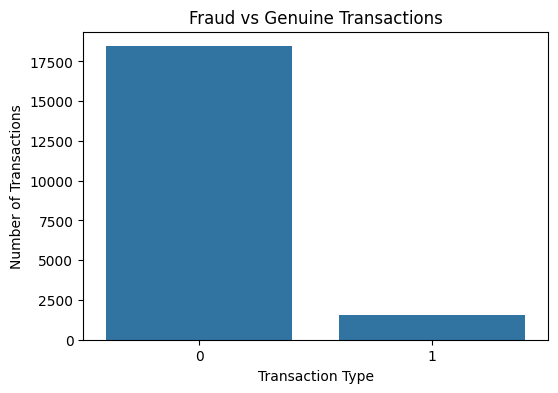

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="is_fraud")

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

In [12]:
print(df["fraud_type"].value_counts())

fraud_type
none                      18447
emerging_anomaly            376
rapid_transactions          262
card_testing                259
account_takeover            229
refund_abuse                217
coordinated_fraud_ring      210
Name: count, dtype: int64


In [13]:
print(
    df["fraud_type"].value_counts(normalize=True) * 100
)

fraud_type
none                      92.235
emerging_anomaly           1.880
rapid_transactions         1.310
card_testing               1.295
account_takeover           1.145
refund_abuse               1.085
coordinated_fraud_ring     1.050
Name: proportion, dtype: float64


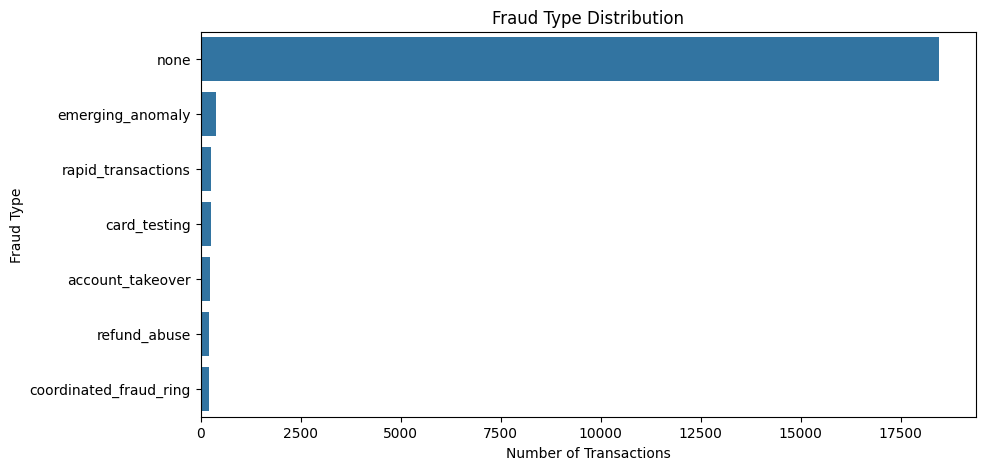

In [14]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="fraud_type",
    order=df["fraud_type"].value_counts().index
)

plt.title("Fraud Type Distribution")
plt.xlabel("Number of Transactions")
plt.ylabel("Fraud Type")

plt.show()

In [15]:
fraud_attack = pd.crosstab(
    df["fraud_type"],
    df["is_fraud"]
)

fraud_attack

is_fraud,0,1
fraud_type,,
account_takeover,0,229
card_testing,0,259
coordinated_fraud_ring,0,210
emerging_anomaly,0,376
none,18447,0
rapid_transactions,0,262
refund_abuse,0,217


In [16]:
df["amount_inr"].describe()

count    20000.000000
mean      2304.933465
std       6528.249554
min         13.230000
25%        498.392500
50%        946.210000
75%       1863.005000
max      89777.680000
Name: amount_inr, dtype: float64

In [17]:
df.groupby("is_fraud")["amount_inr"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,18447.0,1356.360742,1491.531578,28.64,495.49,906.94,1685.86,38875.01
1,1553.0,13572.364900,19621.457376,13.23,767.26,5839.26,17199.90,89777.68


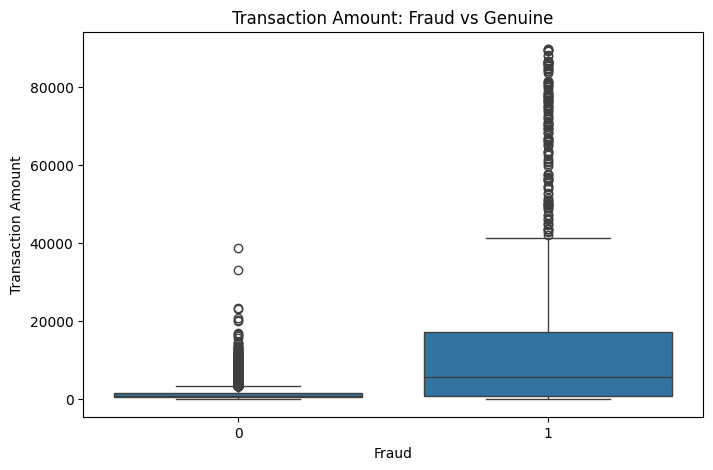

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount_inr"
)

plt.title("Transaction Amount: Fraud vs Genuine")
plt.xlabel("Fraud")
plt.ylabel("Transaction Amount")

plt.show()

In [19]:
entity_columns = [
    "user_id",
    "merchant_id",
    "device_id",
    "ip_id"
]

for column in entity_columns:
    if column in df.columns:
        print(
            f"{column}: {df[column].nunique()} unique values"
        )

user_id: 4949 unique values
merchant_id: 300 unique values
device_id: 6199 unique values
ip_id: 8053 unique values


In [20]:
device_user_counts = (
    df.groupby("device_id")["user_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(device_user_counts.head(20))

device_id
D_RING_07    27
D_RING_05    23
D_RING_02    21
D_RING_01    19
D_RING_06    17
D_RING_03    17
D_RING_08    16
D_RING_04    16
D03168       10
D03003       10
D03320       10
D06202       10
D03302       10
D03470        9
D03065        9
D04430        9
D03014        9
D06161        9
D05408        9
D05451        9
Name: user_id, dtype: int64


In [21]:
suspicious_devices = device_user_counts[
    device_user_counts >= 3
]

print(
    "Devices used by 3+ users:",
    len(suspicious_devices)
)

Devices used by 3+ users: 3835


In [22]:
ip_user_counts = (
    df.groupby("ip_id")["user_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(ip_user_counts.head(20))

ip_id
IP_RING_02    31
IP_RING_04    27
IP_RING_01    26
IP_RING_03    23
IP_RING_05    22
IP08151       10
IP03486       10
IP04907        9
IP04443        9
IP00826        9
IP05460        9
IP08468        9
IP06452        9
IP00385        9
IP08197        8
IP02788        8
IP03857        8
IP07705        8
IP04070        8
IP00189        8
Name: user_id, dtype: int64


In [23]:
suspicious_ips = ip_user_counts[
    ip_user_counts >= 5
]

print(
    "IPs used by 5+ users:",
    len(suspicious_ips)
)

IPs used by 5+ users: 631


In [24]:
print("=" * 50)
print("RAZOR ATTACK LAB - DATA VALIDATION REPORT")
print("=" * 50)

print(f"Total transactions : {len(df):,}")
print(f"Total columns      : {df.shape[1]:,}")
print(f"Duplicate rows     : {df.duplicated().sum():,}")
print(f"Missing values     : {df.isnull().sum().sum():,}")

if "is_fraud" in df.columns:
    fraud_count = df["is_fraud"].sum()
    genuine_count = len(df) - fraud_count

    print(f"Genuine transactions: {genuine_count:,}")
    print(f"Fraud transactions   : {fraud_count:,}")
    print(f"Fraud rate           : {(fraud_count / len(df)) * 100:.2f}%")

if "user_id" in df.columns:
    print(f"Unique users        : {df['user_id'].nunique():,}")

if "device_id" in df.columns:
    print(f"Unique devices      : {df['device_id'].nunique():,}")

if "ip_address" in df.columns:
    print(f"Unique IPs          : {df['ip_address'].nunique():,}")

print("=" * 50)

RAZOR ATTACK LAB - DATA VALIDATION REPORT
Total transactions : 20,000
Total columns      : 24
Duplicate rows     : 0
Missing values     : 0
Genuine transactions: 18,447
Fraud transactions   : 1,553
Fraud rate           : 7.76%
Unique users        : 4,949
Unique devices      : 6,199


## Phase 2 — Feature Engineering

In [25]:
df["timestamp_utc"] = pd.to_datetime(
    df["timestamp_utc"],
    errors="coerce"
)

print(df["timestamp_utc"].dtype)

datetime64[ns, UTC]


In [26]:
df["transaction_hour"] = df["timestamp_utc"].dt.hour

df["day_of_week"] = df["timestamp_utc"].dt.dayofweek

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

In [27]:
df[
    [
        "timestamp_utc",
        "transaction_hour",
        "day_of_week",
        "is_weekend"
    ]
].head()

,timestamp_utc,transaction_hour,day_of_week,is_weekend
0,2026-01-01 10:27:00+00:00,10,3,0
1,2026-01-27 04:00:00+00:00,4,1,0
2,2026-02-24 20:44:00+00:00,20,1,0
3,2026-02-08 11:40:00+00:00,11,6,1
4,2026-02-23 03:42:00+00:00,3,0,0


In [28]:
df["is_night"] = (
    (df["transaction_hour"] < 6) |
    (df["transaction_hour"] >= 23)
).astype(int)

In [29]:
df[
    [
        "transaction_hour",
        "is_night"
    ]
].head()

,transaction_hour,is_night
0,10,0
1,4,1
2,20,0
3,11,0
4,3,1


In [30]:
df["high_amount_deviation"] = (
    df["amount_to_average_ratio"] >= 3
).astype(int)

In [31]:
df["high_velocity"] = (
    (df["transactions_1h"] >= 5) |
    (df["transactions_24h"] >= 20)
).astype(int)

In [32]:
df["shared_infrastructure"] = (
    (df["unique_users_on_device"] >= 3) |
    (df["unique_accounts_on_ip"] >= 5)
).astype(int)

In [33]:
df["new_account_new_device"] = (
    (df["account_age_days"] <= 7) &
    (df["is_new_device"] == 1)
).astype(int)

In [34]:
new_features = [
    "transaction_hour",
    "day_of_week",
    "is_weekend",
    "is_night",
    "high_amount_deviation",
    "high_velocity",
    "shared_infrastructure",
    "new_account_new_device"
]

df[new_features].head()

,transaction_hour,day_of_week,is_weekend,is_night,high_amount_deviation,high_velocity,shared_infrastructure,new_account_new_device
0,10,3,0,0,0,0,0,0
1,4,1,0,1,0,1,0,0
2,20,1,0,0,0,1,0,0
3,11,6,1,0,0,1,0,0
4,3,0,0,1,0,0,1,0


In [35]:
print("New shape:", df.shape)

New shape: (20000, 32)


In [36]:
target = "is_fraud"

drop_columns = [
    "transaction_id",
    "risk_score",
    "recommended_decision",
    "fraud_type",
    "is_fraud",
    "timestamp_utc"
]

X = df.drop(columns=drop_columns)

y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 26)
y shape: (20000,)


In [37]:
X.head()

,user_id,merchant_id,device_id,ip_id,amount_inr,location,payment_method,merchant_category,account_age_days,failed_attempts_24h,transactions_1h,transactions_24h,unique_users_on_device,unique_accounts_on_ip,is_new_device,is_new_location,average_amount_inr,amount_to_average_ratio,transaction_hour,day_of_week,is_weekend,is_night,high_amount_deviation,high_velocity,shared_infrastructure,new_account_new_device
0,U00575,M0173,D02225,IP03001,345.62,Kolkata,UPI,subscriptions,396,5,1,6,2,2,0,0,967.67,0.357,10,3,0,0,0,0,0,0
1,U04711,M0279,D05691,IP00357,13730.66,Jaipur,Netbanking,food,909,0,8,15,1,1,0,0,1526.67,1.781,4,1,0,1,0,1,0,0
2,U00038,M0198,D02340,IP06516,1378.22,Ahmedabad,Wallet,utilities,948,5,5,5,2,1,0,0,971.21,1.419,20,1,0,0,0,1,0,0
3,U01997,M0191,D05995,IP05428,1718.64,Jaipur,Netbanking,utilities,908,0,5,12,1,1,0,0,1512.60,1.136,11,6,1,0,0,1,0,0
4,U03397,M0129,D06141,IP06851,584.50,Kolkata,UPI,education,60,0,1,14,4,1,0,0,1152.14,0.507,3,0,0,1,0,0,1,0


In [38]:
print("New shape:", df.shape)
print(X.dtypes)

New shape: (20000, 32)
user_id                     object
merchant_id                 object
device_id                   object
ip_id                       object
amount_inr                 float64
location                    object
payment_method              object
merchant_category           object
account_age_days             int64
failed_attempts_24h          int64
transactions_1h              int64
transactions_24h             int64
unique_users_on_device       int64
unique_accounts_on_ip        int64
is_new_device                int64
is_new_location              int64
average_amount_inr         float64
amount_to_average_ratio    float64
transaction_hour             int32
day_of_week                  int32
is_weekend                   int64
is_night                     int64
high_amount_deviation        int64
high_velocity                int64
shared_infrastructure        int64
new_account_new_device       int64
dtype: object


## Phase 3 — Categorical Encoding + Train/Test Split

In [39]:
id_columns = [
    "user_id",
    "merchant_id",
    "device_id",
    "ip_id"
]

X_model = X.drop(columns=id_columns)

print("Shape after removing IDs:", X_model.shape)

Shape after removing IDs: (20000, 22)


In [40]:
categorical_columns = [
    "location",
    "payment_method",
    "merchant_category"
]

numeric_columns = [
    column
    for column in X_model.columns
    if column not in categorical_columns
]

print("Categorical columns:")
print(categorical_columns)

print("\nNumeric columns:")
print(numeric_columns)

Categorical columns:
['location', 'payment_method', 'merchant_category']

Numeric columns:
['amount_inr', 'account_age_days', 'failed_attempts_24h', 'transactions_1h', 'transactions_24h', 'unique_users_on_device', 'unique_accounts_on_ip', 'is_new_device', 'is_new_location', 'average_amount_inr', 'amount_to_average_ratio', 'transaction_hour', 'day_of_week', 'is_weekend', 'is_night', 'high_amount_deviation', 'high_velocity', 'shared_infrastructure', 'new_account_new_device']


In [41]:
# Time-based split: train on earlier transactions and evaluate on later ones.
# This better represents how a production risk model sees future payments.
ordered_indices = df.sort_values("timestamp_utc").index
split_point = int(len(ordered_indices) * 0.80)

train_idx = ordered_indices[:split_point]
test_idx = ordered_indices[split_point:]

X_train = X_model.loc[train_idx].copy()
X_test = X_model.loc[test_idx].copy()
y_train = y.loc[train_idx].copy()
y_test = y.loc[test_idx].copy()

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())


Training data: (16000, 22)
Testing data : (4000, 22)

Training target distribution:
is_fraud
0    14756
1     1244
Name: count, dtype: int64

Testing target distribution:
is_fraud
0    3691
1     309
Name: count, dtype: int64


In [42]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [43]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

In [44]:
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape :", X_test_encoded.shape)

Encoded training shape: (16000, 40)
Encoded testing shape : (4000, 40)


In [45]:
feature_names = preprocessor.get_feature_names_out()

print("Total features:", len(feature_names))

for feature in feature_names:
    print(feature)

Total features: 40
categorical__location_Ahmedabad
categorical__location_Bengaluru
categorical__location_Chennai
categorical__location_Delhi
categorical__location_Hyderabad
categorical__location_Jaipur
categorical__location_Kolkata
categorical__location_Lucknow
categorical__location_Mumbai
categorical__location_Pune
categorical__payment_method_Card
categorical__payment_method_Netbanking
categorical__payment_method_UPI
categorical__payment_method_Wallet
categorical__merchant_category_ecommerce
categorical__merchant_category_education
categorical__merchant_category_food
categorical__merchant_category_gaming
categorical__merchant_category_subscriptions
categorical__merchant_category_travel
categorical__merchant_category_utilities
remainder__amount_inr
remainder__account_age_days
remainder__failed_attempts_24h
remainder__transactions_1h
remainder__transactions_24h
remainder__unique_users_on_device
remainder__unique_accounts_on_ip
remainder__is_new_device
remainder__is_new_location
remainde

## Phase 3 — XGBoost Fraud Detection

In [46]:
from xgboost import XGBClassifier

In [47]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 11.861736334405144


In [48]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

In [49]:
model.fit(
    X_train_encoded,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [50]:
y_prob = model.predict_proba(X_test_encoded)[:, 1]

print(y_prob[:10])

[0.17335561 0.03106624 0.02602209 0.01803046 0.06188798 0.77611154
 0.00443334 0.05071056 0.12895453 0.04379226]


In [51]:
y_pred = (y_prob >= 0.5).astype(int)

In [52]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [53]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Genuine", "Fraud"]
    )
)

              precision    recall  f1-score   support

     Genuine       0.98      1.00      0.99      3691
       Fraud       0.93      0.75      0.83       309

    accuracy                           0.98      4000
   macro avg       0.96      0.87      0.91      4000
weighted avg       0.98      0.98      0.98      4000



In [54]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3674   17]
 [  76  233]]


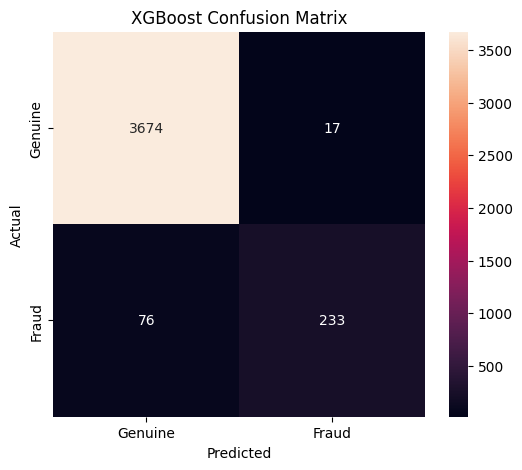

In [55]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [56]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9226255766015299


In [57]:
pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.8423951732000552


In [58]:
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

ROC-AUC : 0.9226
PR-AUC  : 0.8424


In [59]:
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(15)

,feature,importance
24,remainder__transactions_1h,0.100738
21,remainder__amount_inr,0.089168
28,remainder__is_new_device,0.062013
23,remainder__failed_attempts_24h,0.035110
25,remainder__transactions_24h,0.031890
37,remainder__high_velocity,0.031456
36,remainder__high_amount_deviation,0.029139
26,remainder__unique_users_on_device,0.027626
38,remainder__shared_infrastructure,0.025649
29,remainder__is_new_location,0.024792


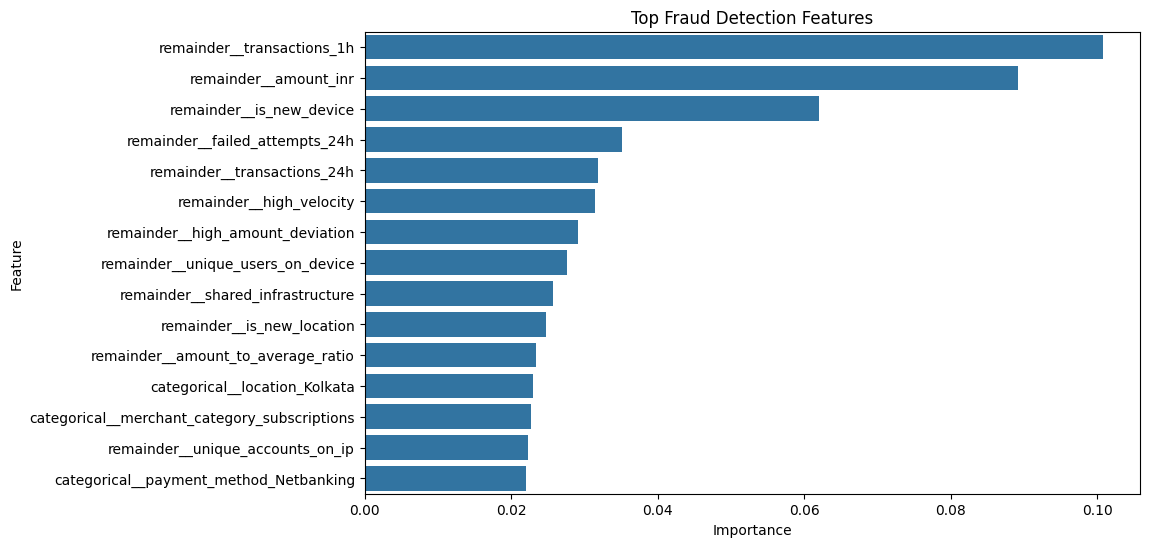

In [60]:
plt.figure(figsize=(10, 6))

top_features = importance.head(15)

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top Fraud Detection Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [61]:
result = X_test.copy()

result["actual_fraud"] = y_test.values
result["fraud_probability"] = y_prob
result["predicted_fraud"] = y_pred

result.head(20)

,amount_inr,location,payment_method,merchant_category,account_age_days,failed_attempts_24h,transactions_1h,transactions_24h,unique_users_on_device,unique_accounts_on_ip,is_new_device,is_new_location,average_amount_inr,amount_to_average_ratio,transaction_hour,day_of_week,is_weekend,is_night,high_amount_deviation,high_velocity,shared_infrastructure,new_account_new_device,actual_fraud,fraud_probability,predicted_fraud
11266,2145.54,Jaipur,Card,travel,361,2,15,24,3,1,0,0,1983.70,1.082,20,1,0,0,0,1,1,0,0,0.173356,0
10082,403.84,Hyderabad,Netbanking,utilities,1089,1,2,3,1,1,0,0,276.96,1.458,20,1,0,0,0,0,0,0,0,0.031066,0
3451,1117.18,Mumbai,UPI,education,725,3,1,20,1,2,0,0,947.02,1.180,20,1,0,0,0,1,0,0,0,0.026022,0
8008,415.19,Chennai,Netbanking,travel,234,1,1,1,1,1,0,0,498.13,0.833,20,1,0,0,0,0,0,0,0,0.018030,0
5415,945.29,Mumbai,UPI,ecommerce,884,0,1,5,1,2,0,0,961.59,0.983,20,1,0,0,0,0,0,0,0,0.061888,0
13177,2843.24,Mumbai,Netbanking,food,1249,1,15,34,2,3,0,0,2941.44,0.967,20,1,0,0,0,1,0,0,0,0.776112,1
12455,466.92,Kolkata,UPI,travel,1368,0,1,8,3,1,0,0,1157.53,0.403,20,1,0,0,0,0,1,0,0,0.004433,0
6173,1983.38,Chennai,Wallet,travel,737,0,6,26,1,2,0,0,406.06,4.884,20,1,0,0,1,1,0,0,0,0.050711,0
14935,261.48,Ahmedabad,Wallet,education,747,4,1,6,1,1,0,0,385.17,0.679,20,1,0,0,0,0,0,0,0,0.128955,0
11127,469.79,Bengaluru,UPI,gaming,108,0,4,13,1,3,0,1,869.74,0.540,20,1,0,0,0,0,0,0,0,0.043792,0


In [62]:
result["ml_risk_score"] = (
    result["fraud_probability"] * 100
).round(2)

In [63]:
# Keep observable transaction features for the policy engine.
# Ground-truth columns are retained only for evaluation, never for decisions.
observable_columns = [
    "transaction_id", "user_id", "merchant_id", "device_id", "ip_id",
    "amount_inr", "location", "payment_method", "merchant_category",
    "account_age_days", "failed_attempts_24h", "transactions_1h",
    "transactions_24h", "unique_users_on_device", "unique_accounts_on_ip",
    "is_new_device", "is_new_location", "average_amount_inr",
    "amount_to_average_ratio", "transaction_hour", "day_of_week",
    "is_weekend", "is_night", "high_amount_deviation", "high_velocity",
    "shared_infrastructure", "new_account_new_device"
]

test_results = df.loc[
    X_test.index,
    observable_columns + ["fraud_type", "is_fraud"]
].copy()

test_results["fraud_probability"] = y_prob
test_results["predicted_fraud"] = y_pred
test_results["ml_risk_score"] = (
    test_results["fraud_probability"] * 100
).round(2)

test_results.head()


,transaction_id,user_id,merchant_id,device_id,ip_id,amount_inr,location,payment_method,merchant_category,account_age_days,failed_attempts_24h,transactions_1h,transactions_24h,unique_users_on_device,unique_accounts_on_ip,is_new_device,is_new_location,average_amount_inr,amount_to_average_ratio,transaction_hour,day_of_week,is_weekend,is_night,high_amount_deviation,high_velocity,shared_infrastructure,new_account_new_device,fraud_type,is_fraud,fraud_probability,predicted_fraud,ml_risk_score
11266,TXN0011267,U01522,M0009,D04714,IP02066,2145.54,Jaipur,Card,travel,361,2,15,24,3,1,0,0,1983.70,1.082,20,1,0,0,0,1,1,0,none,0,0.173356,0,17.34
10082,TXN0010083,U01937,M0172,D03148,IP00255,403.84,Hyderabad,Netbanking,utilities,1089,1,2,3,1,1,0,0,276.96,1.458,20,1,0,0,0,0,0,0,none,0,0.031066,0,3.11
3451,TXN0003452,U03419,M0190,D04202,IP03957,1117.18,Mumbai,UPI,education,725,3,1,20,1,2,0,0,947.02,1.180,20,1,0,0,0,1,0,0,none,0,0.026022,0,2.60
8008,TXN0008009,U04974,M0068,D06368,IP02439,415.19,Chennai,Netbanking,travel,234,1,1,1,1,1,0,0,498.13,0.833,20,1,0,0,0,0,0,0,none,0,0.018030,0,1.80
5415,TXN0005416,U00132,M0223,D04748,IP08887,945.29,Mumbai,UPI,ecommerce,884,0,1,5,1,2,0,0,961.59,0.983,20,1,0,0,0,0,0,0,none,0,0.061888,0,6.19


In [64]:
missed_fraud = test_results[
    (test_results["is_fraud"] == 1) &
    (test_results["predicted_fraud"] == 0)
]

print("Missed fraud transactions:", len(missed_fraud))

missed_fraud.head(20)

Missed fraud transactions: 76


,transaction_id,user_id,merchant_id,device_id,ip_id,amount_inr,location,payment_method,merchant_category,account_age_days,failed_attempts_24h,transactions_1h,transactions_24h,unique_users_on_device,unique_accounts_on_ip,is_new_device,is_new_location,average_amount_inr,amount_to_average_ratio,transaction_hour,day_of_week,is_weekend,is_night,high_amount_deviation,high_velocity,shared_infrastructure,new_account_new_device,fraud_type,is_fraud,fraud_probability,predicted_fraud,ml_risk_score
12593,TXN0012594,U02580,M0261,D02353,IP01328,2283.08,Pune,Netbanking,utilities,1003,0,7,15,1,3,0,0,527.31,2.984,21,1,0,0,0,1,0,0,refund_abuse,1,0.488287,0,48.830002
1850,TXN0001851,U01982,M0011,D00871,IP05361,1392.81,Hyderabad,Wallet,ecommerce,907,1,12,25,2,1,0,1,303.14,4.595,21,1,0,0,1,1,0,0,emerging_anomaly,1,0.167817,0,16.780001
17724,TXN0017725,U00142,M0069,D02976,IP07532,8892.98,Ahmedabad,UPI,gaming,246,0,5,15,1,12,0,0,865.67,5.043,10,2,0,0,1,1,1,0,refund_abuse,1,0.467682,0,46.770000
19775,TXN0019776,U03376,M0157,D00103,IP04044,2958.68,Delhi,UPI,ecommerce,1017,2,2,4,10,1,0,0,689.60,4.290,13,2,0,0,1,0,1,0,emerging_anomaly,1,0.064233,0,6.420000
12883,TXN0012884,U01255,M0290,D00014,IP08638,1036.61,Delhi,UPI,gaming,860,0,8,15,1,1,0,1,1097.93,0.944,17,2,0,0,0,1,0,0,emerging_anomaly,1,0.134329,0,13.430000
10891,TXN0010892,U04808,M0198,D03162,IP05621,538.21,Chennai,UPI,ecommerce,170,1,15,32,1,1,0,0,474.04,1.135,20,2,0,0,0,1,0,0,emerging_anomaly,1,0.058659,0,5.870000
6250,TXN0006251,U03441,M0173,D03202,IP05355,1928.94,Jaipur,Card,utilities,129,0,8,25,1,1,0,0,1195.28,1.614,0,3,0,1,0,1,0,0,emerging_anomaly,1,0.115442,0,11.540000
14784,TXN0014785,U02407,M0119,D02515,IP07056,373.82,Chennai,Netbanking,utilities,815,4,10,13,1,1,0,0,1577.98,0.237,11,3,0,0,0,1,0,0,emerging_anomaly,1,0.051780,0,5.180000
5732,TXN0005733,U03703,M0068,D04031,IP02602,772.60,Bengaluru,Netbanking,subscriptions,1324,0,5,13,1,1,0,0,357.25,2.163,13,3,0,0,0,1,0,0,emerging_anomaly,1,0.123714,0,12.370000
8947,TXN0008948,U01732,M0263,D00236,IP06455,17597.55,Bengaluru,Netbanking,travel,427,0,4,23,1,1,0,0,573.58,30.680,15,3,0,0,1,1,0,0,emerging_anomaly,1,0.302799,0,30.280001


In [65]:
missed_fraud["fraud_type"].value_counts()

fraud_type
emerging_anomaly          68
refund_abuse               7
coordinated_fraud_ring     1
Name: count, dtype: int64

In [66]:
fraud_only = test_results[
    test_results["is_fraud"] == 1
]

attack_performance = (
    fraud_only
    .groupby("fraud_type")
    .agg(
        total_fraud=("is_fraud", "count"),
        detected=("predicted_fraud", "sum")
    )
)

attack_performance["detection_rate"] = (
    attack_performance["detected"] /
    attack_performance["total_fraud"]
)

attack_performance.sort_values(
    "detection_rate"
)

,total_fraud,detected,detection_rate
fraud_type,,,
emerging_anomaly,70,2,0.028571
refund_abuse,40,33,0.825000
coordinated_fraud_ring,50,49,0.980000
card_testing,54,54,1.000000
account_takeover,45,45,1.000000
rapid_transactions,50,50,1.000000


## Phase 4 — Isolation Forest

In [67]:
from sklearn.ensemble import IsolationForest

In [68]:
anomaly_features = [
    "amount_inr",
    "account_age_days",
    "failed_attempts_24h",
    "transactions_1h",
    "transactions_24h",
    "unique_users_on_device",
    "unique_accounts_on_ip",
    "is_new_device",
    "is_new_location",
    "average_amount_inr",
    "amount_to_average_ratio",
    "transaction_hour",
    "is_weekend",
    "is_night",
    "high_amount_deviation",
    "high_velocity",
    "shared_infrastructure",
    "new_account_new_device"
]

In [69]:
print(len(anomaly_features))

18


In [70]:
X_anomaly_train = df.loc[
    X_train.index,
    anomaly_features
]

X_anomaly_test = df.loc[
    X_test.index,
    anomaly_features
]

print(X_anomaly_train.shape)
print(X_anomaly_test.shape)

(16000, 18)
(4000, 18)


In [71]:
isolation_model = IsolationForest(
    n_estimators=300,
    contamination=0.08,
    random_state=42,
    n_jobs=-1
)

In [72]:
isolation_model.fit(X_anomaly_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.08
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [73]:
anomaly_prediction = isolation_model.predict(
    X_anomaly_test
)

In [74]:
print(pd.Series(anomaly_prediction).value_counts())

 1    3650
-1     350
Name: count, dtype: int64


In [75]:
anomaly_flag = (
    anomaly_prediction == -1
).astype(int)

print(pd.Series(anomaly_flag).value_counts())

0    3650
1     350
Name: count, dtype: int64


In [76]:
# Fit the anomaly score scaler on training data only.
raw_anomaly_train = -isolation_model.score_samples(X_anomaly_train)
raw_anomaly_score = -isolation_model.score_samples(X_anomaly_test)


In [77]:
from sklearn.preprocessing import MinMaxScaler

In [78]:
anomaly_scaler = MinMaxScaler(feature_range=(0, 100))
anomaly_scaler.fit(raw_anomaly_train.reshape(-1, 1))

anomaly_score = anomaly_scaler.transform(
    raw_anomaly_score.reshape(-1, 1)
).ravel()


In [79]:
test_results["anomaly_flag"] = anomaly_flag

test_results["anomaly_score"] = (
    anomaly_score.round(2)
)

In [80]:
test_results[
    [
        "transaction_id",
        "fraud_type",
        "is_fraud",
        "ml_risk_score",
        "anomaly_flag",
        "anomaly_score"
    ]
].head(20)

,transaction_id,fraud_type,is_fraud,ml_risk_score,anomaly_flag,anomaly_score
11266,TXN0011267,none,0,17.340000,0,40.59
10082,TXN0010083,none,0,3.110000,0,8.08
3451,TXN0003452,none,0,2.600000,0,14.56
8008,TXN0008009,none,0,1.800000,0,10.26
5415,TXN0005416,none,0,6.190000,0,5.00
13177,TXN0013178,none,0,77.610001,0,49.89
12455,TXN0012456,none,0,0.440000,0,18.96
6173,TXN0006174,none,0,5.070000,0,27.38
14935,TXN0014936,none,0,12.900000,0,10.50
11127,TXN0011128,none,0,4.380000,0,26.11


In [81]:
fraud_anomaly_analysis = test_results[
    test_results["is_fraud"] == 1
].copy()

anomaly_performance = (
    fraud_anomaly_analysis
    .groupby("fraud_type")
    .agg(
        total_fraud=("is_fraud", "count"),
        detected_anomaly=("anomaly_flag", "sum")
    )
)

anomaly_performance["anomaly_detection_rate"] = (
    anomaly_performance["detected_anomaly"] /
    anomaly_performance["total_fraud"]
)

anomaly_performance.sort_values(
    "anomaly_detection_rate",
    ascending=False
)

,total_fraud,detected_anomaly,anomaly_detection_rate
fraud_type,,,
account_takeover,45,45,1.000000
coordinated_fraud_ring,50,50,1.000000
card_testing,54,49,0.907407
rapid_transactions,50,36,0.720000
emerging_anomaly,70,11,0.157143
refund_abuse,40,5,0.125000


In [82]:
print(
    test_results[
        test_results["fraud_type"] == "emerging_anomaly"
    ][
        [
            "fraud_type",
            "is_fraud",
            "ml_risk_score",
            "anomaly_flag",
            "anomaly_score"
        ]
    ].sort_values(
        "anomaly_score",
        ascending=False
    ).head(20)
)

             fraud_type  is_fraud  ml_risk_score  anomaly_flag  anomaly_score
9976   emerging_anomaly         1      43.330002             1          69.73
10986  emerging_anomaly         1       9.120000             1          69.54
19972  emerging_anomaly         1      11.480000             1          60.31
7282   emerging_anomaly         1      33.419998             1          59.57
3510   emerging_anomaly         1       4.810000             1          58.24
14492  emerging_anomaly         1      40.980000             1          58.03
11368  emerging_anomaly         1      44.549999             1          57.91
8728   emerging_anomaly         1      17.440001             1          55.72
4805   emerging_anomaly         1      67.540001             1          55.63
8947   emerging_anomaly         1      30.280001             1          55.26
12271  emerging_anomaly         1      32.910000             1          53.31
1850   emerging_anomaly         1      16.780001             0  

## Phase 5 — Fraud Network Graph

In [83]:
import networkx as nx

In [84]:
G = nx.Graph()

In [85]:
# Use historical training activity to build graph risk.
# Test labels remain available in graph_data only for later evaluation/reporting.
graph_columns = [
    "transaction_id", "user_id", "device_id", "ip_id", "merchant_id"
]

graph_history = df.loc[
    X_train.index,
    graph_columns
].copy()

graph_data = df.loc[
    X_test.index,
    graph_columns + ["is_fraud", "fraud_type"]
].copy()

print("Historical graph data:", graph_history.shape)
print("Evaluation graph data:", graph_data.shape)


Historical graph data: (16000, 5)
Evaluation graph data: (4000, 7)


In [86]:
for _, row in graph_data.iterrows():

    G.add_node(
        row["user_id"],
        node_type="user"
    )

    G.add_node(
        row["device_id"],
        node_type="device"
    )

    G.add_node(
        row["ip_id"],
        node_type="ip"
    )

    G.add_node(
        row["merchant_id"],
        node_type="merchant"
    )

In [87]:
for _, row in graph_data.iterrows():

    G.add_edge(
        row["user_id"],
        row["device_id"],
        relationship="uses"
    )

In [88]:
for _, row in graph_data.iterrows():

    G.add_edge(
        row["user_id"],
        row["ip_id"],
        relationship="connects"
    )

In [89]:
for _, row in graph_data.iterrows():

    G.add_edge(
        row["user_id"],
        row["merchant_id"],
        relationship="pays"
    )

In [90]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 9234
Edges: 11983


In [91]:
degree_dict = dict(G.degree())

degree_df = pd.DataFrame(
    degree_dict.items(),
    columns=["node", "degree"]
)

degree_df = degree_df.sort_values(
    "degree",
    ascending=False
)

degree_df.head(20)

,node,degree
531,M0018,23
1395,M0189,23
1403,M0211,23
539,M0244,23
835,M0078,23
113,M0246,22
201,M0150,22
362,M0099,21
1803,M0292,21
457,M0080,21


In [92]:
device_stats = (
    graph_data
    .groupby("device_id")
    .agg(
        unique_users=("user_id", "nunique"),
        transactions=("transaction_id", "count")
    )
    .sort_values(
        "unique_users",
        ascending=False
    )
)

device_stats.head(20)

,unique_users,transactions
device_id,,
D_RING_05,9,9
D_RING_04,8,8
D_RING_07,7,7
D_RING_06,6,6
D04955,5,5
D_RING_02,5,8
D_RING_03,5,5
D04240,4,4
D05483,4,4


In [93]:
device_stats["device_risk"] = (
    device_stats["unique_users"] >= 3
).astype(int)

In [94]:
ip_stats = (
    graph_data
    .groupby("ip_id")
    .agg(
        unique_users=("user_id", "nunique"),
        unique_devices=("device_id", "nunique"),
        transactions=("transaction_id", "count")
    )
    .sort_values(
        "unique_users",
        ascending=False
    )
)

ip_stats.head(20)

,unique_users,unique_devices,transactions
ip_id,,,
IP_RING_02,13,7,15
IP_RING_03,10,7,10
IP_RING_01,9,8,11
IP_RING_04,8,6,8
IP_RING_05,6,5,6
IP05731,4,4,4
IP08151,4,4,4
IP00243,4,4,4
IP04096,4,4,4


In [95]:
fraud_graph_data = graph_data[
    graph_data["is_fraud"] == 1
]

device_fraud_stats = (
    fraud_graph_data
    .groupby("device_id")
    .agg(
        fraud_transactions=("transaction_id", "count"),
        unique_fraud_users=("user_id", "nunique")
    )
    .sort_values(
        "fraud_transactions",
        ascending=False
    )
)

device_fraud_stats.head(20)

,fraud_transactions,unique_fraud_users
device_id,,
D_RING_05,9,9
D_RING_02,8,5
D_RING_04,8,8
D_RING_07,7,7
D_RING_06,6,6
D_RING_03,5,5
D_RING_01,4,3
D_RING_08,3,3
D00863,2,2


In [96]:
fraud_ring_candidates = device_fraud_stats[
    (device_fraud_stats["fraud_transactions"] >= 2) &
    (device_fraud_stats["unique_fraud_users"] >= 2)
]

print(
    "Potential fraud-ring devices:",
    len(fraud_ring_candidates)
)

fraud_ring_candidates.head(20)

Potential fraud-ring devices: 16


,fraud_transactions,unique_fraud_users
device_id,,
D_RING_05,9,9
D_RING_02,8,5
D_RING_04,8,8
D_RING_07,7,7
D_RING_06,6,6
D_RING_03,5,5
D_RING_01,4,3
D_RING_08,3,3
D00863,2,2


### Graph Risk Engine

In [97]:
# Device risk uses only observable historical connectivity.
device_risk = (
    graph_history
    .groupby("device_id")
    .agg(
        unique_users=("user_id", "nunique"),
        unique_ips=("ip_id", "nunique"),
        total_transactions=("transaction_id", "count")
    )
)

device_risk.head()


,unique_users,unique_ips,total_transactions
device_id,,,
D00001,2,2,2
D00002,1,1,1
D00003,3,3,3
D00004,3,3,3
D00005,3,3,3


In [98]:
device_risk["shared_user_score"] = (
    ((device_risk["unique_users"] - 1) / 7)
    .clip(0, 1)
)

device_risk["shared_ip_score"] = (
    ((device_risk["unique_ips"] - 1) / 4)
    .clip(0, 1)
)


In [99]:
# No current-row fraud label is used here.
device_risk["graph_risk_score"] = (
    device_risk["shared_user_score"] * 55
    + device_risk["shared_ip_score"] * 45
)


In [100]:
device_risk["graph_risk_score"] = (
    device_risk["graph_risk_score"]
    .clip(0, 100)
    .round(2)
)

In [101]:
device_risk.sort_values(
    "graph_risk_score",
    ascending=False
).head(20)

,unique_users,unique_ips,total_transactions,shared_user_score,shared_ip_score,graph_risk_score
device_id,,,,,,
D_RING_01,16,5,21,1.0,1.0,100.0
D_RING_08,15,5,16,1.0,1.0,100.0
D_RING_07,23,5,29,1.0,1.0,100.0
D03168,10,10,10,1.0,1.0,100.0
D03138,8,8,8,1.0,1.0,100.0
D03339,8,8,8,1.0,1.0,100.0
D03320,8,8,8,1.0,1.0,100.0
D03725,8,8,8,1.0,1.0,100.0
D03014,8,8,8,1.0,1.0,100.0


In [102]:
ip_risk = (
    graph_history
    .groupby("ip_id")
    .agg(
        unique_users=("user_id", "nunique"),
        unique_devices=("device_id", "nunique"),
        total_transactions=("transaction_id", "count")
    )
)

ip_risk.head()


,unique_users,unique_devices,total_transactions
ip_id,,,
IP00003,2,2,2
IP00004,1,1,1
IP00005,1,1,1
IP00006,3,3,3
IP00007,3,3,3


In [103]:
ip_risk["shared_user_score"] = (
    ((ip_risk["unique_users"] - 1) / 9)
    .clip(0, 1)
)

ip_risk["shared_device_score"] = (
    ((ip_risk["unique_devices"] - 1) / 6)
    .clip(0, 1)
)


In [104]:
# IP risk also uses only connectivity signals available before scoring.
ip_risk["graph_risk_score"] = (
    ip_risk["shared_user_score"] * 55
    + ip_risk["shared_device_score"] * 45
)

ip_risk["graph_risk_score"] = (
    ip_risk["graph_risk_score"]
    .clip(0, 100)
    .round(2)
)


In [105]:
ip_risk.sort_values(
    "graph_risk_score",
    ascending=False
).head(20)

,unique_users,unique_devices,total_transactions,shared_user_score,shared_device_score,graph_risk_score
ip_id,,,,,,
IP_RING_02,22,8,30,1.000000,1.0,100.00
IP_RING_01,22,8,30,1.000000,1.0,100.00
IP_RING_05,18,8,26,1.000000,1.0,100.00
IP_RING_04,23,8,41,1.000000,1.0,100.00
IP_RING_03,20,8,33,1.000000,1.0,100.00
IP03486,9,9,9,0.888889,1.0,93.89
IP08468,9,9,9,0.888889,1.0,93.89
IP04907,9,9,9,0.888889,1.0,93.89
IP00826,9,9,9,0.888889,1.0,93.89


In [106]:
device_score_map = device_risk[
    "graph_risk_score"
].to_dict()



In [107]:
ip_score_map = ip_risk[
    "graph_risk_score"
].to_dict()

In [108]:
test_results["device_graph_score"] = (
    test_results["device_id"]
    .map(device_score_map)
    .fillna(0)
)

test_results["ip_graph_score"] = (
    test_results["ip_id"]
    .map(ip_score_map)
    .fillna(0)
)

In [109]:
test_results["graph_risk_score"] = (
    0.6 * test_results["device_graph_score"]
    +
    0.4 * test_results["ip_graph_score"]
).round(2)


In [110]:
test_results[
    test_results["fraud_type"] == "coordinated_fraud_ring"
][
    [
        "fraud_type",
        "device_id",
        "ip_id",
        "graph_risk_score"
    ]
].sort_values(
    "graph_risk_score",
    ascending=False
).head(20)

,fraud_type,device_id,ip_id,graph_risk_score
8749,coordinated_fraud_ring,D_RING_06,IP_RING_02,100.0
2111,coordinated_fraud_ring,D_RING_02,IP_RING_02,100.0
591,coordinated_fraud_ring,D_RING_06,IP_RING_03,100.0
8600,coordinated_fraud_ring,D_RING_02,IP_RING_02,100.0
3309,coordinated_fraud_ring,D_RING_06,IP_RING_01,100.0
11562,coordinated_fraud_ring,D_RING_05,IP_RING_01,100.0
16553,coordinated_fraud_ring,D_RING_04,IP_RING_04,100.0
11065,coordinated_fraud_ring,D_RING_05,IP_RING_01,100.0
17846,coordinated_fraud_ring,D_RING_06,IP_RING_05,100.0
16568,coordinated_fraud_ring,D_RING_03,IP_RING_02,100.0


## Phase 6 — Actual RazorAttackLab Risk Engine

In [111]:
# anomaly_score was already scaled using the training distribution.
test_results["anomaly_risk_score"] = (
    test_results["anomaly_score"]
).round(2)


In [112]:
test_results[
    [
        "ml_risk_score",
        "anomaly_score",
        "anomaly_risk_score",
        "graph_risk_score"
    ]
].head(10)

,ml_risk_score,anomaly_score,anomaly_risk_score,graph_risk_score
11266,17.340000,40.59,40.59,45.86
10082,3.110000,8.08,8.08,11.47
3451,2.600000,14.56,14.56,22.35
8008,1.800000,10.26,10.26,34.39
5415,6.190000,5.00,5.00,33.81
13177,77.610001,49.89,49.89,51.30
12455,0.440000,18.96,18.96,22.35
6173,5.070000,27.38,27.38,16.91
14935,12.900000,10.50,10.50,34.39
11127,4.380000,26.11,26.11,28.37


In [113]:
test_results["final_risk_score"] = (
    0.50 * test_results["ml_risk_score"]
    +
    0.20 * test_results["anomaly_risk_score"]
    +
    0.30 * test_results["graph_risk_score"]
).clip(0, 100).round(2)

In [114]:
def make_decision(score):

    if score >= 85:
        return "BLOCK"

    elif score >= 65:
        return "REVIEW"

    elif score >= 40:
        return "VERIFY"

    else:
        return "ALLOW"

In [115]:
test_results["recommended_action"] = (
    test_results["final_risk_score"]
    .apply(make_decision)
)

In [116]:
test_results[
    [
        "is_fraud",
        "fraud_type",
        "ml_risk_score",
        "anomaly_risk_score",
        "graph_risk_score",
        "final_risk_score",
        "recommended_action"
    ]
].head(20)

,is_fraud,fraud_type,ml_risk_score,anomaly_risk_score,graph_risk_score,final_risk_score,recommended_action
11266,0,none,17.340000,40.59,45.86,30.55,ALLOW
10082,0,none,3.110000,8.08,11.47,6.61,ALLOW
3451,0,none,2.600000,14.56,22.35,10.92,ALLOW
8008,0,none,1.800000,10.26,34.39,13.27,ALLOW
5415,0,none,6.190000,5.00,33.81,14.24,ALLOW
13177,0,none,77.610001,49.89,51.30,64.17,VERIFY
12455,0,none,0.440000,18.96,22.35,10.72,ALLOW
6173,0,none,5.070000,27.38,16.91,13.08,ALLOW
14935,0,none,12.900000,10.50,34.39,18.87,ALLOW
11127,0,none,4.380000,26.11,28.37,15.92,ALLOW


In [117]:
pd.crosstab(
    test_results["fraud_type"],
    test_results["recommended_action"]
)

recommended_action,ALLOW,BLOCK,REVIEW,VERIFY
fraud_type,,,,
account_takeover,0,0,42,3
card_testing,0,0,41,13
coordinated_fraud_ring,0,48,2,0
emerging_anomaly,67,0,0,3
none,3665,0,1,25
rapid_transactions,0,0,34,16
refund_abuse,5,0,8,27


In [118]:
## fraud vs genuine check
pd.crosstab(
    test_results["is_fraud"],
    test_results["recommended_action"],
    normalize="index"
).round(3)

recommended_action,ALLOW,BLOCK,REVIEW,VERIFY
is_fraud,,,,
0,0.993,0.000,0.000,0.007
1,0.233,0.155,0.411,0.201


In [119]:
fraud_blocked = (
    (test_results["is_fraud"] == 1) &
    (test_results["recommended_action"] == "BLOCK")
).sum()

total_fraud = (
    test_results["is_fraud"] == 1
).sum()

fraud_prevention_rate = (
    fraud_blocked / total_fraud * 100
)

print(
    f"Fraud prevention rate: "
    f"{fraud_prevention_rate:.2f}%"
)

Fraud prevention rate: 15.53%


In [120]:
genuine_blocked = (
    (test_results["is_fraud"] == 0) &
    (test_results["recommended_action"] == "BLOCK")
).sum()

total_genuine = (
    test_results["is_fraud"] == 0
).sum()

false_block_rate = (
    genuine_blocked / total_genuine * 100
)

print(
    f"Genuine customer block rate: "
    f"{false_block_rate:.2f}%"
)

Genuine customer block rate: 0.00%


### Smart Policy Engine

In [121]:
def risk_decision(row):

    final_score = row["final_risk_score"]
    graph_score = row["graph_risk_score"]

    # Strong coordinated fraud infrastructure
    if graph_score >= 85:
        return "BLOCK"

    # Very high overall risk
    if final_score >= 85:
        return "BLOCK"

    # High risk
    if final_score >= 65:
        return "REVIEW"

    # Medium risk
    if final_score >= 40:
        return "VERIFY"

    return "ALLOW"

In [122]:
def policy_decision(row):
    """Decision policy based only on features observable at payment time."""
    final_score = row["final_risk_score"]
    graph_score = row["graph_risk_score"]

    # Coordinated infrastructure signal.
    if (
        row["unique_users_on_device"] >= 5
        and row["unique_accounts_on_ip"] >= 5
        and row["shared_infrastructure"] == 1
    ):
        return "BLOCK"

    # High velocity can indicate card testing or automation.
    if (
        row["transactions_1h"] >= 15
        or row["transactions_24h"] >= 30
    ) and final_score >= 55:
        return "BLOCK"

    # New device + location change + failed attempts suggests takeover.
    if (
        row["is_new_device"] == 1
        and row["is_new_location"] == 1
        and row["failed_attempts_24h"] >= 3
        and final_score >= 50
    ):
        return "VERIFY"

    # Strong graph risk deserves an intervention even if ML is uncertain.
    if graph_score >= 75:
        return "REVIEW"

    if final_score >= 85:
        return "BLOCK"
    if final_score >= 65:
        return "REVIEW"
    if final_score >= 40:
        return "VERIFY"
    return "ALLOW"
    


In [123]:
test_results["policy_action"] = (
    test_results.apply(policy_decision, axis=1)
)

In [124]:
pd.crosstab(
    test_results["fraud_type"],
    test_results["policy_action"]
)

policy_action,ALLOW,BLOCK,REVIEW,VERIFY
fraud_type,,,,
account_takeover,0,0,5,40
card_testing,0,47,2,5
coordinated_fraud_ring,0,50,0,0
emerging_anomaly,65,2,0,3
none,3639,28,3,21
rapid_transactions,0,50,0,0
refund_abuse,5,0,8,27


In [125]:
fraud_blocked = (
    (test_results["is_fraud"] == 1) &
    (test_results["policy_action"] == "BLOCK")
).sum()

total_fraud = (
    test_results["is_fraud"] == 1
).sum()

print(
    "Fraud blocked:",
    fraud_blocked,
    "/",
    total_fraud
)

print(
    "Fraud prevention rate:",
    round(
        fraud_blocked / total_fraud * 100,
        2
    ),
    "%"
)

Fraud blocked: 149 / 309
Fraud prevention rate: 48.22 %


In [126]:
genuine_blocked = (
    (test_results["is_fraud"] == 0) &
    (test_results["policy_action"] == "BLOCK")
).sum()

total_genuine = (
    test_results["is_fraud"] == 0
).sum()

print(
    "Genuine customer block rate:",
    round(
        genuine_blocked / total_genuine * 100,
        2
    ),
    "%"
)

Genuine customer block rate: 0.76 %


In [127]:
# at different threshold
def simulate_policy(df, block_threshold, review_threshold, verify_threshold):

    def decision(score):
        if score >= block_threshold:
            return "BLOCK"
        elif score >= review_threshold:
            return "REVIEW"
        elif score >= verify_threshold:
            return "VERIFY"
        else:
            return "ALLOW"

    actions = df["final_risk_score"].apply(decision)

    fraud = df["is_fraud"] == 1
    genuine = df["is_fraud"] == 0

    fraud_blocked = ((actions == "BLOCK") & fraud).sum()
    genuine_blocked = ((actions == "BLOCK") & genuine).sum()

    total_fraud = fraud.sum()
    total_genuine = genuine.sum()

    return {
        "block_threshold": block_threshold,
        "fraud_prevention_rate": round(
            fraud_blocked / total_fraud * 100, 2
        ),
        "genuine_block_rate": round(
            genuine_blocked / total_genuine * 100, 2
        ),
        "fraud_blocked": fraud_blocked,
        "total_fraud": total_fraud
    }

In [128]:
policies = [
    (85, 65, 40),
    (80, 60, 40),
    (75, 55, 40),
    (70, 50, 35),
    (65, 45, 35)
]

results = []

for block, review, verify in policies:

    result = simulate_policy(
        test_results,
        block,
        review,
        verify
    )

    results.append(result)

policy_results = pd.DataFrame(results)

policy_results

,block_threshold,fraud_prevention_rate,genuine_block_rate,fraud_blocked,total_fraud
0,85,15.53,0.00,48,309
1,80,17.15,0.00,53,309
2,75,26.21,0.00,81,309
3,70,39.16,0.00,121,309
4,65,56.63,0.03,175,309


In [129]:
def evaluate_policy(df, block_threshold, review_threshold, verify_threshold):

    def decision(score):
        if score >= block_threshold:
            return "BLOCK"
        elif score >= review_threshold:
            return "REVIEW"
        elif score >= verify_threshold:
            return "VERIFY"
        else:
            return "ALLOW"

    actions = df["final_risk_score"].apply(decision)

    fraud = df["is_fraud"] == 1
    genuine = df["is_fraud"] == 0

    total_fraud = fraud.sum()
    total_genuine = genuine.sum()

    fraud_blocked = ((actions == "BLOCK") & fraud).sum()
    fraud_reviewed = ((actions == "REVIEW") & fraud).sum()
    fraud_verified = ((actions == "VERIFY") & fraud).sum()
    fraud_allowed = ((actions == "ALLOW") & fraud).sum()

    genuine_blocked = ((actions == "BLOCK") & genuine).sum()
    genuine_reviewed = ((actions == "REVIEW") & genuine).sum()
    genuine_verified = ((actions == "VERIFY") & genuine).sum()
    genuine_allowed = ((actions == "ALLOW") & genuine).sum()

    return {
        "block_threshold": block_threshold,

        "fraud_prevention_rate":
            round(fraud_blocked / total_fraud * 100, 2),

        "genuine_block_rate":
            round(genuine_blocked / total_genuine * 100, 2),

        "fraud_blocked": fraud_blocked,
        "fraud_reviewed": fraud_reviewed,
        "fraud_verified": fraud_verified,
        "fraud_allowed": fraud_allowed,

        "genuine_blocked": genuine_blocked,
        "genuine_reviewed": genuine_reviewed,
        "genuine_verified": genuine_verified,
        "genuine_allowed": genuine_allowed
    }

In [130]:
policies = [
    (85, 65, 40),
    (80, 60, 40),
    (75, 55, 40),
    (70, 50, 35),
    (65, 45, 35)
]

results = []

for block, review, verify in policies:

    result = evaluate_policy(
        test_results,
        block,
        review,
        verify
    )

    results.append(result)

policy_results = pd.DataFrame(results)

policy_results

,block_threshold,fraud_prevention_rate,genuine_block_rate,fraud_blocked,fraud_reviewed,fraud_verified,fraud_allowed,genuine_blocked,genuine_reviewed,genuine_verified,genuine_allowed
0,85,15.53,0.00,48,127,62,72,0,1,25,3665
1,80,17.15,0.00,53,161,23,72,0,5,21,3665
2,75,26.21,0.00,81,148,8,72,0,6,20,3665
3,70,39.16,0.00,121,110,12,66,0,7,42,3642
4,65,56.63,0.03,175,59,9,66,1,10,38,3642


## Phase 7 — Evidence Engine :"Why is this transaction risky?

In [131]:
# SHAP is optional. XGBoost's native contribution values are a safe fallback.
try:
    import shap
    SHAP_BACKEND = "shap"
except ImportError:
    import xgboost as xgb
    SHAP_BACKEND = "xgboost_native"


In [132]:
X_test_transformed = preprocessor.transform(X_test)

if SHAP_BACKEND == "shap":
    explainer = shap.TreeExplainer(model)
else:
    explainer = None


In [133]:
if SHAP_BACKEND == "shap":
    shap_values = explainer.shap_values(X_test_transformed)
else:
    native_values = model.get_booster().predict(
        xgb.DMatrix(X_test_transformed),
        pred_contribs=True
    )
    # The last column is the bias term, not a feature contribution.
    shap_values = native_values[:, :-1]


In [134]:
print("Explainability backend:", SHAP_BACKEND)
print("SHAP/contribution matrix:", np.asarray(shap_values).shape)


Explainability backend: shap
SHAP/contribution matrix: (4000, 40)


In [135]:

feature_names = preprocessor.get_feature_names_out()

def get_top_shap_reasons(index, top_n=5):

    values = shap_values[index]

    importance = np.abs(values)

    top_indices = np.argsort(
        importance
    )[-top_n:][::-1]

    reasons = []

    for i in top_indices:

        reasons.append({
            "feature": feature_names[i],
            "shap_value": round(float(values[i]), 4),
            "importance": round(float(importance[i]), 4)
        })

    return pd.DataFrame(reasons)

In [136]:
# 0 th trans kai liye 
get_top_shap_reasons(0)

,feature,shap_value,importance
0,remainder__transactions_1h,1.4083,1.4083
1,remainder__average_amount_inr,-1.1288,1.1288
2,remainder__amount_inr,-0.4672,0.4672
3,remainder__transactions_24h,-0.4619,0.4619
4,remainder__is_new_device,-0.3397,0.3397


In [137]:
feature_explanations = {

    "amount_inr":
        "Transaction amount",

    "transactions_1h":
        "High transaction velocity in the last hour",

    "transactions_24h":
        "High transaction activity in the last 24 hours",

    "amount_to_average_ratio":
        "Transaction amount is unusual compared with the user's average",

    "failed_attempts_24h":
        "Multiple failed payment attempts in the last 24 hours",

    "account_age_days":
        "Account age",

    "unique_users_on_device":
        "Multiple users are associated with the same device",

    "unique_accounts_on_ip":
        "Multiple accounts are associated with the same IP",

    "is_new_device":
        "Transaction is coming from a new device",

    "is_new_location":
        "Transaction is coming from a new location",

    "high_amount_deviation":
        "Transaction amount is significantly higher than normal",

    "high_velocity":
        "Unusually high transaction velocity",

    "shared_infrastructure":
        "Device or IP infrastructure is shared across multiple users",

    "new_account_new_device":
        "New account is using a new device",

    "transaction_hour":
        "Transaction time",

    "day_of_week":
        "Transaction day",

    "is_weekend":
        "Transaction occurred during the weekend",

    "is_night":
        "Transaction occurred during nighttime"
}

In [138]:
def clean_feature_name(feature):

    feature = feature.replace(
        "remainder__",
        ""
    )

    feature = feature.replace(
        "categorical__",
        ""
    )

    return feature

In [139]:
def get_shap_explanation(index, top_n=5):

    values = shap_values[index]

    importance = np.abs(values)

    top_indices = np.argsort(
        importance
    )[-top_n:][::-1]

    explanations = []

    for i in top_indices:

        raw_feature = feature_names[i]

        feature = clean_feature_name(
            raw_feature
        )

        shap_value = float(values[i])

        explanation = feature_explanations.get(
            feature,
            feature
        )

        explanations.append({

            "feature": feature,

            "shap_value":
                round(shap_value, 4),

            "impact":
                "increases fraud risk"
                if shap_value > 0
                else
                "decreases fraud risk",

            "explanation":
                explanation
        })

    return pd.DataFrame(
        explanations
    )

In [140]:
get_shap_explanation(0)

,feature,shap_value,impact,explanation
0,transactions_1h,1.4083,increases fraud risk,High transaction velocity in the last hour
1,average_amount_inr,-1.1288,decreases fraud risk,average_amount_inr
2,amount_inr,-0.4672,decreases fraud risk,Transaction amount
3,transactions_24h,-0.4619,decreases fraud risk,High transaction activity in the last 24 hours
4,is_new_device,-0.3397,decreases fraud risk,Transaction is coming from a new device


In [141]:
# High risk Transaction
fraud_test = test_results[
    test_results["is_fraud"] == 1
].copy()

fraud_test[
    [
        "final_risk_score",
        "ml_risk_score",
        "anomaly_risk_score",
        "graph_risk_score",
        "recommended_action",
        "fraud_type"
    ]
].sort_values(
    "final_risk_score",
    ascending=False
).head(10)

,final_risk_score,ml_risk_score,anomaly_risk_score,graph_risk_score,recommended_action,fraud_type
14544,99.87,99.279999,101.13,100.0,BLOCK,coordinated_fraud_ring
2450,99.23,99.930000,96.34,100.0,BLOCK,coordinated_fraud_ring
15776,98.73,99.910004,93.85,100.0,BLOCK,coordinated_fraud_ring
9945,98.60,99.720001,93.71,100.0,BLOCK,coordinated_fraud_ring
7617,98.33,99.849998,92.02,100.0,BLOCK,coordinated_fraud_ring
9226,98.29,99.910004,91.65,100.0,BLOCK,coordinated_fraud_ring
9544,98.20,99.980003,91.03,100.0,BLOCK,coordinated_fraud_ring
5131,98.09,99.959999,90.53,100.0,BLOCK,coordinated_fraud_ring
5252,97.97,99.989998,89.90,100.0,BLOCK,coordinated_fraud_ring
10979,97.92,99.029999,92.04,100.0,BLOCK,coordinated_fraud_ring


In [142]:
# Pick a valid, high-risk test row instead of relying on a hard-coded index.
idx = test_results["final_risk_score"].idxmax()
transaction = test_results.loc[idx]
transaction


transaction_id                         TXN0014545
user_id                                U_RING_025
merchant_id                                 M0095
device_id                               D_RING_01
ip_id                                  IP_RING_01
amount_inr                                5885.33
location                                  Chennai
payment_method                               Card
merchant_category                       utilities
account_age_days                                6
failed_attempts_24h                             0
transactions_1h                                 8
transactions_24h                               10
unique_users_on_device                         16
unique_accounts_on_ip                          17
is_new_device                                   1
is_new_location                                 1
average_amount_inr                         404.73
amount_to_average_ratio                     3.253
transaction_hour                                3


In [143]:
position = test_results.index.get_loc(idx)
print("test_results position:", position)


test_results position: 1117


In [144]:
get_top_shap_reasons(position)


,feature,shap_value,importance
0,remainder__amount_inr,1.9121,1.9121
1,remainder__unique_users_on_device,0.9749,0.9749
2,remainder__unique_accounts_on_ip,0.8908,0.8908
3,remainder__is_new_device,0.6391,0.6391
4,remainder__transactions_1h,0.4773,0.4773


In [145]:
device_id = transaction["device_id"]
ip_id = transaction["ip_id"]

print("Device:", device_id)
print("IP:", ip_id)


Device: D_RING_01
IP: IP_RING_01


In [146]:
print(device_risk.reindex([device_id]).fillna(0))


           unique_users  unique_ips  total_transactions  shared_user_score  \
device_id                                                                    
D_RING_01            16           5                  21                1.0   

           shared_ip_score  graph_risk_score  
device_id                                     
D_RING_01              1.0             100.0  


In [147]:
print(ip_risk.reindex([ip_id]).fillna(0))


            unique_users  unique_devices  total_transactions  \
ip_id                                                          
IP_RING_01            22               8                  30   

            shared_user_score  shared_device_score  graph_risk_score  
ip_id                                                                 
IP_RING_01                1.0                  1.0             100.0  


In [148]:
# Connectivity counts come from historical activity only.
device_users = graph_history[
    graph_history["device_id"] == device_id
]["user_id"].nunique()

device_ips = graph_history[
    graph_history["device_id"] == device_id
]["ip_id"].nunique()

print("Historical users on device:", device_users)
print("Historical IPs on device:", device_ips)


Historical users on device: 16
Historical IPs on device: 5


In [149]:
ip_users = graph_history[
    graph_history["ip_id"] == ip_id
]["user_id"].nunique()

ip_devices = graph_history[
    graph_history["ip_id"] == ip_id
]["device_id"].nunique()

print("Historical users on IP:", ip_users)
print("Historical devices on IP:", ip_devices)


Historical users on IP: 22
Historical devices on IP: 8


In [150]:
def build_risk_evidence(
    idx,
    test_results,
    device_risk,
    ip_risk,
    shap_position,
    shap_top_n=5
):
    """Build an evidence object without using future fraud labels."""
    transaction = test_results.loc[idx]

    device_id = transaction["device_id"]
    ip_id = transaction["ip_id"]

    shap_df = get_shap_explanation(
        shap_position,
        top_n=shap_top_n
    )

    ml_evidence = []
    for _, item in shap_df.iterrows():
        if item["shap_value"] > 0:
            ml_evidence.append({
                "feature": item["feature"],
                "impact": "increases fraud risk",
                "reason": item["explanation"],
                "shap_value": float(item["shap_value"])
            })

    def lookup(table, key, defaults):
        if key in table.index:
            return table.loc[key]
        return pd.Series(defaults)

    device = lookup(
        device_risk,
        device_id,
        {
            "unique_users": 0,
            "unique_ips": 0,
            "total_transactions": 0,
            "graph_risk_score": 0
        }
    )
    ip = lookup(
        ip_risk,
        ip_id,
        {
            "unique_users": 0,
            "unique_devices": 0,
            "total_transactions": 0,
            "graph_risk_score": 0
        }
    )

    device_evidence = {
        "device_id": device_id,
        "unique_users": int(device["unique_users"]),
        "unique_ips": int(device["unique_ips"]),
        "total_transactions": int(device["total_transactions"]),
        "graph_risk_score": float(device["graph_risk_score"])
    }
    ip_evidence = {
        "ip_id": ip_id,
        "unique_users": int(ip["unique_users"]),
        "unique_devices": int(ip["unique_devices"]),
        "total_transactions": int(ip["total_transactions"]),
        "graph_risk_score": float(ip["graph_risk_score"])
    }

    evidence = {
        "transaction": {
            "transaction_id": transaction["transaction_id"],
            "user_id": transaction["user_id"],
            "merchant_id": transaction["merchant_id"],
            "device_id": device_id,
            "ip_id": ip_id,
            "amount_inr": float(transaction["amount_inr"]),
            "amount_to_average_ratio": float(
                transaction["amount_to_average_ratio"]
            ),
            "transactions_1h": int(transaction["transactions_1h"]),
            "transactions_24h": int(transaction["transactions_24h"]),
            "failed_attempts_24h": int(transaction["failed_attempts_24h"]),
            "is_new_device": int(transaction["is_new_device"]),
            "is_new_location": int(transaction["is_new_location"]),
            "shared_infrastructure": int(
                transaction["shared_infrastructure"]
            )
        },
        # These fields are for offline evaluation and never drive the score.
        "evaluation": {
            "actual_fraud": int(transaction["is_fraud"]),
            "fraud_type": transaction["fraud_type"]
        },
        "decision": {
            "recommended_action": transaction["recommended_action"],
            "policy_action": transaction["policy_action"]
        },
        "risk_scores": {
            "ml_risk": float(transaction["ml_risk_score"]),
            "anomaly_risk": float(transaction["anomaly_risk_score"]),
            "device_graph_risk": float(device["graph_risk_score"]),
            "ip_graph_risk": float(ip["graph_risk_score"]),
            "final_risk": float(transaction["final_risk_score"])
        },
        "ml_evidence": ml_evidence,
        "graph_evidence": {
            "device": device_evidence,
            "ip": ip_evidence
        },
        "anomaly": {
            "anomaly_flag": int(transaction["anomaly_flag"]),
            "anomaly_score": float(transaction["anomaly_score"])
        }
    }
    return evidence
    


In [151]:
position = test_results.index.get_loc(idx)

risk_evidence = build_risk_evidence(
    idx=idx,
    test_results=test_results,
    device_risk=device_risk,
    ip_risk=ip_risk,
    shap_position=position
)


In [152]:
risk_evidence

{'transaction': {'transaction_id': 'TXN0014545',
  'user_id': 'U_RING_025',
  'merchant_id': 'M0095',
  'device_id': 'D_RING_01',
  'ip_id': 'IP_RING_01',
  'amount_inr': 5885.33,
  'amount_to_average_ratio': 3.253,
  'transactions_1h': 8,
  'transactions_24h': 10,
  'failed_attempts_24h': 0,
  'is_new_device': 1,
  'is_new_location': 1,
  'shared_infrastructure': 1},
 'evaluation': {'actual_fraud': 1, 'fraud_type': 'coordinated_fraud_ring'},
 'decision': {'recommended_action': 'BLOCK', 'policy_action': 'BLOCK'},
 'risk_scores': {'ml_risk': 99.27999877929688,
  'anomaly_risk': 101.13,
  'device_graph_risk': 100.0,
  'ip_graph_risk': 100.0,
  'final_risk': 99.87},
 'ml_evidence': [{'feature': 'amount_inr',
   'impact': 'increases fraud risk',
   'reason': 'Transaction amount',
   'shap_value': 1.9121},
  {'feature': 'unique_users_on_device',
   'impact': 'increases fraud risk',
   'reason': 'Multiple users are associated with the same device',
   'shap_value': 0.9749},
  {'feature': 'un

In [153]:
import json

print(
    json.dumps(
        risk_evidence,
        indent=4,
        default=str
    )
)

{
    "transaction": {
        "transaction_id": "TXN0014545",
        "user_id": "U_RING_025",
        "merchant_id": "M0095",
        "device_id": "D_RING_01",
        "ip_id": "IP_RING_01",
        "amount_inr": 5885.33,
        "amount_to_average_ratio": 3.253,
        "transactions_1h": 8,
        "transactions_24h": 10,
        "failed_attempts_24h": 0,
        "is_new_device": 1,
        "is_new_location": 1,
        "shared_infrastructure": 1
    },
    "evaluation": {
        "actual_fraud": 1,
        "fraud_type": "coordinated_fraud_ring"
    },
    "decision": {
        "recommended_action": "BLOCK",
        "policy_action": "BLOCK"
    },
    "risk_scores": {
        "ml_risk": 99.27999877929688,
        "anomaly_risk": 101.13,
        "device_graph_risk": 100.0,
        "ip_graph_risk": 100.0,
        "final_risk": 99.87
    },
    "ml_evidence": [
        {
            "feature": "amount_inr",
            "impact": "increases fraud risk",
            "reason": "Transacti

In [154]:
def generate_attack_story(evidence):
    tx = evidence["transaction"]
    risk = evidence["risk_scores"]
    graph = evidence["graph_evidence"]
    device = graph["device"]
    ip = graph["ip"]
    reasons = []

    if device["unique_users"] >= 5:
        reasons.append(
            f'Device {device["device_id"]} is associated with '
            f'{device["unique_users"]} historical users.'
        )
    if ip["unique_users"] >= 5:
        reasons.append(
            f'IP {ip["ip_id"]} is shared across '
            f'{ip["unique_users"]} users and '
            f'{ip["unique_devices"]} devices.'
        )
    if tx["transactions_1h"] >= 15:
        reasons.append("Transaction velocity is unusually high.")
    if (
        tx["is_new_device"] == 1
        and tx["is_new_location"] == 1
        and tx["failed_attempts_24h"] >= 3
    ):
        reasons.append(
            "A new device and location appeared alongside repeated failures."
        )
    if tx["amount_to_average_ratio"] >= 3:
        reasons.append(
            "The amount is substantially higher than the user's average."
        )
    for item in evidence["ml_evidence"]:
        reasons.append(item["reason"])
    if evidence["anomaly"]["anomaly_flag"] == 1:
        reasons.append(
            f'Anomaly detection flagged this transaction with a score of '
            f'{evidence["anomaly"]["anomaly_score"]:.2f}.'
        )

    story = (
        f'High-risk transaction detected. Transaction {tx["transaction_id"]} '
        f'involves a payment of ₹{tx["amount_inr"]:,.2f}. '
        f'The combined risk score is {risk["final_risk"]:.2f}/100. '
    )
    if reasons:
        story += "Observed evidence: " + " ".join(reasons) + " "
    story += (
        f'Recommended action: '
        f'{evidence["decision"]["recommended_action"]}.'
    )
    return story


In [155]:
attack_story = generate_attack_story(
    risk_evidence
)

print(attack_story)

High-risk transaction detected. Transaction TXN0014545 involves a payment of ₹5,885.33. The combined risk score is 99.87/100. Observed evidence: Device D_RING_01 is associated with 16 historical users. IP IP_RING_01 is shared across 22 users and 8 devices. The amount is substantially higher than the user's average. Transaction amount Multiple users are associated with the same device Multiple accounts are associated with the same IP Transaction is coming from a new device High transaction velocity in the last hour Anomaly detection flagged this transaction with a score of 101.13. Recommended action: BLOCK.


In [156]:
def add_attack_type_evidence(evidence):
    """Infer a possible pattern from observable signals only."""
    tx = evidence["transaction"]
    device = evidence["graph_evidence"]["device"]
    ip = evidence["graph_evidence"]["ip"]
    attack_evidence = []

    if device["unique_users"] >= 5 and ip["unique_users"] >= 5:
        attack_evidence.append(
            "The infrastructure pattern is consistent with coordinated activity."
        )
    if tx["transactions_1h"] >= 15 or tx["transactions_24h"] >= 30:
        attack_evidence.append(
            "The velocity pattern is consistent with automated or card-testing activity."
        )
    if (
        tx["is_new_device"] == 1
        and tx["is_new_location"] == 1
        and tx["failed_attempts_24h"] >= 3
    ):
        attack_evidence.append(
            "The context is consistent with account-takeover-like behavior."
        )
    if tx["amount_to_average_ratio"] >= 3:
        attack_evidence.append(
            "The amount deviation is consistent with unusual payment behavior."
        )
    if not attack_evidence and evidence["anomaly"]["anomaly_flag"] == 1:
        attack_evidence.append(
            "The transaction shows an emerging anomaly relative to historical behavior."
        )

    evidence["attack_type_evidence"] = attack_evidence
    return evidence
    


In [157]:
risk_evidence = add_attack_type_evidence(
    risk_evidence
)

In [158]:
risk_evidence["attack_type_evidence"]

['The infrastructure pattern is consistent with coordinated activity.',
 'The amount deviation is consistent with unusual payment behavior.']

## PHASE 8 — AI Risk Analyst

In [159]:
print(risk_evidence.keys())

dict_keys(['transaction', 'evaluation', 'decision', 'risk_scores', 'ml_evidence', 'graph_evidence', 'anomaly', 'attack_type_evidence'])


In [160]:
for key, value in risk_evidence.items():
    print("\nKEY:", key)
    print("TYPE:", type(value))
    
    if isinstance(value, dict):
        print("SUB-KEYS:", value.keys())
    else:
        print("VALUE:", value)


KEY: transaction
TYPE: <class 'dict'>
SUB-KEYS: dict_keys(['transaction_id', 'user_id', 'merchant_id', 'device_id', 'ip_id', 'amount_inr', 'amount_to_average_ratio', 'transactions_1h', 'transactions_24h', 'failed_attempts_24h', 'is_new_device', 'is_new_location', 'shared_infrastructure'])

KEY: evaluation
TYPE: <class 'dict'>
SUB-KEYS: dict_keys(['actual_fraud', 'fraud_type'])

KEY: decision
TYPE: <class 'dict'>
SUB-KEYS: dict_keys(['recommended_action', 'policy_action'])

KEY: risk_scores
TYPE: <class 'dict'>
SUB-KEYS: dict_keys(['ml_risk', 'anomaly_risk', 'device_graph_risk', 'ip_graph_risk', 'final_risk'])

KEY: ml_evidence
TYPE: <class 'list'>
VALUE: [{'feature': 'amount_inr', 'impact': 'increases fraud risk', 'reason': 'Transaction amount', 'shap_value': 1.9121}, {'feature': 'unique_users_on_device', 'impact': 'increases fraud risk', 'reason': 'Multiple users are associated with the same device', 'shap_value': 0.9749}, {'feature': 'unique_accounts_on_ip', 'impact': 'increases fra

In [161]:
def build_ai_evidence(evidence):
    # Deliberately exclude actual_fraud and fraud_type.
    # The AI explanation must rely only on observable evidence.
    return {
        "transaction": evidence["transaction"],
        "decision": evidence["decision"],
        "risk_scores": evidence["risk_scores"],
        "ml_evidence": evidence["ml_evidence"],
        "graph_evidence": evidence["graph_evidence"],
        "anomaly": evidence["anomaly"],
        "attack_type_evidence": evidence.get(
            "attack_type_evidence", []
        )
    }


In [162]:
ai_evidence = build_ai_evidence(risk_evidence)

ai_evidence

{'transaction': {'transaction_id': 'TXN0014545',
  'user_id': 'U_RING_025',
  'merchant_id': 'M0095',
  'device_id': 'D_RING_01',
  'ip_id': 'IP_RING_01',
  'amount_inr': 5885.33,
  'amount_to_average_ratio': 3.253,
  'transactions_1h': 8,
  'transactions_24h': 10,
  'failed_attempts_24h': 0,
  'is_new_device': 1,
  'is_new_location': 1,
  'shared_infrastructure': 1},
 'decision': {'recommended_action': 'BLOCK', 'policy_action': 'BLOCK'},
 'risk_scores': {'ml_risk': 99.27999877929688,
  'anomaly_risk': 101.13,
  'device_graph_risk': 100.0,
  'ip_graph_risk': 100.0,
  'final_risk': 99.87},
 'ml_evidence': [{'feature': 'amount_inr',
   'impact': 'increases fraud risk',
   'reason': 'Transaction amount',
   'shap_value': 1.9121},
  {'feature': 'unique_users_on_device',
   'impact': 'increases fraud risk',
   'reason': 'Multiple users are associated with the same device',
   'shap_value': 0.9749},
  {'feature': 'unique_accounts_on_ip',
   'impact': 'increases fraud risk',
   'reason': 'Mul

In [163]:
def create_risk_analyst_prompt(evidence):
    return f"""
You are the Risk Analyst AI inside RazorAttackLab.
This is synthetic demo data, not real Razorpay data.

Use only the observable evidence below. Do not claim fraud as a fact.
Use words such as "suggests" or "is consistent with" when interpreting.

TRANSACTION
{json.dumps(evidence["transaction"], indent=2, default=str)}

RISK SCORES
{json.dumps(evidence["risk_scores"], indent=2, default=str)}

GRAPH EVIDENCE
{json.dumps(evidence["graph_evidence"], indent=2, default=str)}

ANOMALY EVIDENCE
{json.dumps(evidence["anomaly"], indent=2, default=str)}

MODEL EVIDENCE
{json.dumps(evidence["ml_evidence"], indent=2, default=str)}

PATTERN SIGNALS
{json.dumps(evidence["attack_type_evidence"], indent=2, default=str)}

Return exactly:
Risk Summary:
<2-3 sentences>

Observed Evidence:
- <evidence>
- <evidence>
- <evidence>

Why Suspicious:
<2-4 sentences>

Likely Attack Pattern:
<pattern, clearly marked as a possibility>

Recommended Action:
<action and short justification>

Attack Story:
<2-4 sentences, without inventing events>
"""
    


In [164]:
risk_analyst_prompt = create_risk_analyst_prompt(ai_evidence)

print(risk_analyst_prompt)


You are the Risk Analyst AI inside RazorAttackLab.
This is synthetic demo data, not real Razorpay data.

Use only the observable evidence below. Do not claim fraud as a fact.
Use words such as "suggests" or "is consistent with" when interpreting.

TRANSACTION
{
  "transaction_id": "TXN0014545",
  "user_id": "U_RING_025",
  "merchant_id": "M0095",
  "device_id": "D_RING_01",
  "ip_id": "IP_RING_01",
  "amount_inr": 5885.33,
  "amount_to_average_ratio": 3.253,
  "transactions_1h": 8,
  "transactions_24h": 10,
  "failed_attempts_24h": 0,
  "is_new_device": 1,
  "is_new_location": 1,
  "shared_infrastructure": 1
}

RISK SCORES
{
  "ml_risk": 99.27999877929688,
  "anomaly_risk": 101.13,
  "device_graph_risk": 100.0,
  "ip_graph_risk": 100.0,
  "final_risk": 99.87
}

GRAPH EVIDENCE
{
  "device": {
    "device_id": "D_RING_01",
    "unique_users": 16,
    "unique_ips": 5,
    "total_transactions": 21,
    "graph_risk_score": 100.0
  },
  "ip": {
    "ip_id": "IP_RING_01",
    "unique_users":

## API use

In [170]:
import os
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

api_key = os.getenv("GROQ_API_KEY")

if not api_key:
    raise ValueError(
        "GROQ_API_KEY not found. Check your .env file."
    )

client = Groq(api_key=api_key)

print("Groq API configured successfully.")

Groq API configured successfully.


In [171]:
if client is not None:
    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[{
            "role": "user",
            "content": "Reply with exactly: RazorAttackLab API working"
        }],
        temperature=0
    )
    print(response.choices[0].message.content)
else:
    print("Skipped API smoke test.")


RazorAttackLab API working


In [172]:
def call_groq(prompt, system_prompt=None):
    if client is None:
        raise RuntimeError(
            "Groq is not configured. The core notebook can run without it."
        )

    messages = []
    if system_prompt:
        messages.append({
            "role": "system",
            "content": system_prompt
        })
    messages.append({"role": "user", "content": prompt})

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=messages,
        temperature=0.2,
        max_tokens=700
    )
    return response.choices[0].message.content


In [173]:
if client is not None:
    result = call_groq(
        "Explain in one sentence what fraud detection means."
    )
    print(result)
else:
    print("Skipped optional AI explanation test.")


Fraud detection is the systematic identification and prevention of deceptive or illicit activities by analyzing patterns, anomalies, and behaviors to flag potentially fraudulent transactions or actions.


In [175]:
if client is not None:
    ai_response = call_groq(
        risk_analyst_prompt,
        system_prompt=(
            "Explain risk using only the supplied evidence. "
            "Never claim synthetic data is real or reveal hidden labels."
        )
    )
    print(ai_response)
else:
    ai_response = (
        "Optional AI layer skipped. The structured evidence and "
        "deterministic attack story are still available."
    )
    print(ai_response)


Risk Summary:  
The transaction shows multiple high‑risk indicators, including elevated machine‑learning, anomaly, device, and IP graph scores, a large amount deviation, and a new device/location. These factors together suggest the activity may be suspicious.  

Observed Evidence:  
- Risk scores: ml_risk 99.28, anomaly_risk 101.13, device_graph_risk 100, ip_graph_risk 100, final_risk


## Attack scenario framework

In [176]:
# ============================================
# ATTACK SCENARIO GENERATOR
# ============================================

import numpy as np
import pandas as pd
from copy import deepcopy


class AttackScenarioGenerator:

    def __init__(self, df, random_state=42):
        self.df = df.copy()
        self.rng = np.random.default_rng(random_state)

    def card_testing(self, n_transactions=20):

        base = self.df.sample(
            n=min(n_transactions, len(self.df)),
            random_state=42
        ).copy()

        base["attack_scenario"] = "card_testing"

        base["amount_inr"] = self.rng.uniform(
            10, 500, size=len(base)
        )

        base["transactions_1h"] = self.rng.integers(
            5, 15, size=len(base)
        )

        base["transactions_24h"] = (
            base["transactions_1h"]
            + self.rng.integers(5, 20, size=len(base))
        )

        base["high_velocity"] = 1

        return base

    def account_takeover(self, n_transactions=20):

        base = self.df.sample(
            n=min(n_transactions, len(self.df)),
            random_state=43
        ).copy()

        base["attack_scenario"] = "account_takeover"

        base["is_new_device"] = 1
        base["is_new_location"] = 1

        base["failed_attempts_24h"] = self.rng.integers(
            3, 10, size=len(base)
        )

        base["amount_to_average_ratio"] = self.rng.uniform(
            2.0, 6.0, size=len(base)
        )

        base["high_amount_deviation"] = 1

        return base

    def rapid_transactions(self, n_transactions=20):

        base = self.df.sample(
            n=min(n_transactions, len(self.df)),
            random_state=44
        ).copy()

        base["attack_scenario"] = "rapid_transactions"

        base["transactions_1h"] = self.rng.integers(
            15, 40, size=len(base)
        )

        base["transactions_24h"] = self.rng.integers(
            30, 80, size=len(base)
        )

        base["high_velocity"] = 1

        return base

    def refund_abuse(self, n_transactions=20):

        base = self.df.sample(
            n=min(n_transactions, len(self.df)),
            random_state=45
        ).copy()

        base["attack_scenario"] = "refund_abuse"

        base["amount_to_average_ratio"] = self.rng.uniform(
            2.0, 5.0, size=len(base)
        )

        base["high_amount_deviation"] = 1

        return base

    def coordinated_fraud_ring(self, n_transactions=20):

        base = self.df.sample(
            n=min(n_transactions, len(self.df)),
            random_state=46
        ).copy()

        base["attack_scenario"] = "coordinated_fraud_ring"

        base["unique_users_on_device"] = self.rng.integers(
            5, 12, size=len(base)
        )

        base["unique_accounts_on_ip"] = self.rng.integers(
            5, 12, size=len(base)
        )

        base["shared_infrastructure"] = 1
        base["is_new_device"] = 1

        return base

    def generate_all(self, n_each=20):

        attacks = pd.concat(
            [
                self.card_testing(n_each),
                self.account_takeover(n_each),
                self.rapid_transactions(n_each),
                self.refund_abuse(n_each),
                self.coordinated_fraud_ring(n_each)
            ],
            ignore_index=True
        )

        return attacks


print("✅ AttackScenarioGenerator loaded successfully")

✅ AttackScenarioGenerator loaded successfully


In [177]:
def card_testing(self, n_transactions=20):

    base = self.df.sample(
        n=min(n_transactions, len(self.df)),
        random_state=42
    ).copy()

    base["attack_scenario"] = "card_testing"

    # Small repeated transactions
    base["amount_inr"] = self.rng.uniform(
        10, 500, size=len(base)
    )

    base["transactions_1h"] = self.rng.integers(
        8, 20, size=len(base)
    )

    base["transactions_24h"] = (
        base["transactions_1h"] +
        self.rng.integers(10, 30, size=len(base))
    )

    # Failed payment attempts
    base["failed_attempts_24h"] = self.rng.integers(
        3, 10, size=len(base)
    )

    base["high_velocity"] = 1

    base["is_new_device"] = self.rng.choice(
        [0, 1],
        size=len(base),
        p=[0.3, 0.7]
    )

    return base

In [178]:
def account_takeover(self, n_transactions=20):

    base = self.df.sample(
        n=min(n_transactions, len(self.df)),
        random_state=43
    ).copy()

    base["attack_scenario"] = "account_takeover"

    base["is_new_device"] = 1
    base["is_new_location"] = 1

    base["failed_attempts_24h"] = self.rng.integers(
        5, 12, size=len(base)
    )

    base["amount_to_average_ratio"] = self.rng.uniform(
        3.0, 8.0, size=len(base)
    )

    base["high_amount_deviation"] = 1

    base["transactions_1h"] = self.rng.integers(
        4, 12, size=len(base)
    )

    base["high_velocity"] = 1

    base["new_account_new_device"] = 1

    return base

In [179]:
def rapid_transactions(self, n_transactions=20):

    base = self.df.sample(
        n=min(n_transactions, len(self.df)),
        random_state=44
    ).copy()

    base["attack_scenario"] = "rapid_transactions"

    base["transactions_1h"] = self.rng.integers(
        20, 50, size=len(base)
    )

    base["transactions_24h"] = self.rng.integers(
        50, 120, size=len(base)
    )

    base["failed_attempts_24h"] = self.rng.integers(
        2, 8, size=len(base)
    )

    base["high_velocity"] = 1

    return base

In [180]:
def refund_abuse(self, n_transactions=20):

    base = self.df.sample(
        n=min(n_transactions, len(self.df)),
        random_state=45
    ).copy()

    base["attack_scenario"] = "refund_abuse"

    # Unusual transaction amount
    base["amount_to_average_ratio"] = self.rng.uniform(
        3.0, 8.0, size=len(base)
    )

    base["high_amount_deviation"] = 1

    # Repeated suspicious activity
    base["transactions_1h"] = self.rng.integers(
        5, 15, size=len(base)
    )

    base["transactions_24h"] = self.rng.integers(
        15, 40, size=len(base)
    )

    # Failed attempts
    base["failed_attempts_24h"] = self.rng.integers(
        2, 7, size=len(base)
    )

    # Suspicious context
    base["is_new_location"] = self.rng.choice(
        [0, 1],
        size=len(base),
        p=[0.2, 0.8]
    )

    base["is_new_device"] = self.rng.choice(
        [0, 1],
        size=len(base),
        p=[0.3, 0.7]
    )

    base["high_velocity"] = 1

    return base

In [181]:
def coordinated_fraud_ring(self, n_transactions=20):

    base = self.df.sample(
        n=min(n_transactions, len(self.df)),
        random_state=46
    ).copy()

    base["attack_scenario"] = "coordinated_fraud_ring"

    # Shared infrastructure
    base["unique_users_on_device"] = self.rng.integers(
        5, 12, size=len(base)
    )

    base["unique_accounts_on_ip"] = self.rng.integers(
        5, 12, size=len(base)
    )

    base["shared_infrastructure"] = 1

    base["is_new_device"] = 1

    base["is_new_location"] = 1

    base["failed_attempts_24h"] = self.rng.integers(
        2, 8, size=len(base)
    )

    base["amount_to_average_ratio"] = self.rng.uniform(
        2.0, 6.0, size=len(base)
    )

    base["high_amount_deviation"] = 1

    base["high_velocity"] = 1

    return base

In [182]:
attack_generator = AttackScenarioGenerator(
    df,
    random_state=42
)

attack_data = attack_generator.generate_all(
    n_each=20
)

print("Attack dataset:", attack_data.shape)

print(
    attack_data["attack_scenario"]
    .value_counts()
)

Attack dataset: (100, 33)
attack_scenario
card_testing              20
account_takeover          20
rapid_transactions        20
refund_abuse              20
coordinated_fraud_ring    20
Name: count, dtype: int64


In [183]:
# ============================================================
# COMPLETE ATTACK RISK SIMULATOR
# XGBoost + Isolation Forest + Graph Risk + Policy Engine
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. COPY ATTACK DATA
# ------------------------------------------------------------

attack_test = attack_data.copy()

print("===================================================")
print("ATTACK SIMULATION")
print("===================================================")

print("Attack dataset:", attack_test.shape)

print("\nAttack scenarios:")
print(
    attack_test["attack_scenario"].value_counts()
)


# ============================================================
# 2. XGBOOST ML RISK
# ============================================================

print("\n===================================================")
print("1. XGBOOST ML RISK")
print("===================================================")

# EXACT features used by XGBoost
X_attack_ml = attack_test[
    X_model.columns
].copy()

print(
    "XGBoost input shape:",
    X_attack_ml.shape
)

# Same preprocessing used during training
X_attack_ml_encoded = preprocessor.transform(
    X_attack_ml
)

print(
    "Encoded XGBoost shape:",
    X_attack_ml_encoded.shape
)

# Fraud probability
attack_test["fraud_probability"] = (
    model.predict_proba(
        X_attack_ml_encoded
    )[:, 1]
)

# ML risk 0-100
attack_test["ml_risk_score"] = (
    attack_test["fraud_probability"] * 100
)

# ML prediction
attack_test["predicted_fraud"] = (
    attack_test["fraud_probability"] >= 0.5
).astype(int)

print("\nML risk calculated.")


# ============================================================
# 3. ISOLATION FOREST
# ============================================================

print("\n===================================================")
print("2. ISOLATION FOREST ANOMALY RISK")
print("===================================================")

# ------------------------------------------------------------
# VERY IMPORTANT
# Isolation Forest was trained on 18 features.
# DO NOT give it XGBoost's 40 encoded features.
# ------------------------------------------------------------

iso_features = list(
    isolation_model.feature_names_in_
)

print(
    "Isolation Forest expects:",
    isolation_model.n_features_in_
)

print(
    "Isolation Forest features:"
)

print(iso_features)


# Check missing features
missing_iso_features = [
    col
    for col in iso_features
    if col not in attack_test.columns
]

print(
    "\nMissing Isolation Forest features:",
    missing_iso_features
)


if len(missing_iso_features) > 0:

    raise ValueError(
        "Attack dataset is missing Isolation Forest features: "
        + str(missing_iso_features)
    )


# Correct Isolation Forest input
X_attack_iso = attack_test[
    iso_features
].copy()

print(
    "\nIsolation Forest input shape:",
    X_attack_iso.shape
)


# ------------------------------------------------------------
# Anomaly prediction
# ------------------------------------------------------------

attack_test["anomaly_flag"] = (
    isolation_model.predict(
        X_attack_iso
    ) == -1
).astype(int)


# ------------------------------------------------------------
# Raw anomaly score
# ------------------------------------------------------------

raw_anomaly_score = (
    isolation_model.decision_function(
        X_attack_iso
    )
)


# ------------------------------------------------------------
# Convert anomaly score → 0-100
#
# Lower decision_function = more anomalous
# ------------------------------------------------------------

score_min = raw_anomaly_score.min()
score_max = raw_anomaly_score.max()

if score_max == score_min:

    attack_test["anomaly_risk_score"] = 50.0

else:

    attack_test["anomaly_risk_score"] = (
        1 -
        (
            (raw_anomaly_score - score_min)
            /
            (score_max - score_min)
        )
    ) * 100


attack_test["anomaly_risk_score"] = (
    attack_test[
        "anomaly_risk_score"
    ]
    .clip(0, 100)
)


print("\nAnomaly risk calculated.")


# ============================================================
# 4. GRAPH RISK
# ============================================================

print("\n===================================================")
print("3. GRAPH RISK")
print("===================================================")


# ------------------------------------------------------------
# Device Graph Risk
# ------------------------------------------------------------

attack_test["device_graph_risk"] = (
    attack_test["device_id"]
    .map(device_score_map)
    .fillna(0)
)


# ------------------------------------------------------------
# IP Graph Risk
# ------------------------------------------------------------

attack_test["ip_graph_risk"] = (
    attack_test["ip_id"]
    .map(ip_score_map)
    .fillna(0)
)


# ------------------------------------------------------------
# Combined Graph Risk
#
# Device = 60%
# IP     = 40%
# ------------------------------------------------------------

attack_test["graph_risk_score"] = (
    0.60 *
    attack_test["device_graph_risk"]
    +
    0.40 *
    attack_test["ip_graph_risk"]
)


attack_test["graph_risk_score"] = (
    attack_test["graph_risk_score"]
    .clip(0, 100)
)


print("\nGraph risk calculated.")


# ============================================================
# 5. FINAL RISK SCORE
# ============================================================

print("\n===================================================")
print("4. FINAL RISK SCORE")
print("===================================================")


# ------------------------------------------------------------
# Final Risk Formula
#
# ML Risk       = 50%
# Anomaly Risk  = 25%
# Graph Risk    = 25%
# ------------------------------------------------------------

attack_test["final_risk_score"] = (

    0.50 *
    attack_test["ml_risk_score"]

    +

    0.25 *
    attack_test["anomaly_risk_score"]

    +

    0.25 *
    attack_test["graph_risk_score"]

)


attack_test["final_risk_score"] = (
    attack_test["final_risk_score"]
    .clip(0, 100)
)


print("\nFinal risk calculated.")


# ============================================================
# 6. POLICY ENGINE
# ============================================================

print("\n===================================================")
print("5. POLICY ENGINE")
print("===================================================")


def policy_engine(row):

    risk = row["final_risk_score"]
    anomaly = row["anomaly_flag"]

    # -----------------------------------------
    # Very high risk
    # -----------------------------------------

    if risk >= 85:
        return "BLOCK"

    # -----------------------------------------
    # High risk / strong anomaly
    # -----------------------------------------

    elif risk >= 70 or anomaly == 1:
        return "VERIFY"

    # -----------------------------------------
    # Medium risk
    # -----------------------------------------

    elif risk >= 50:
        return "REVIEW"

    # -----------------------------------------
    # Low risk
    # -----------------------------------------

    else:
        return "ALLOW"


attack_test["policy_action"] = (
    attack_test.apply(
        policy_engine,
        axis=1
    )
)


print("\nPolicy decisions generated.")


# ============================================================
# 7. COMPLETE RESULT TABLE
# ============================================================

print("\n===================================================")
print("6. COMPLETE ATTACK RESULTS")
print("===================================================")


result_columns = [

    # Attack
    "attack_scenario",

    # ML
    "predicted_fraud",
    "fraud_probability",
    "ml_risk_score",

    # Anomaly
    "anomaly_flag",
    "anomaly_risk_score",

    # Graph
    "device_graph_risk",
    "ip_graph_risk",
    "graph_risk_score",

    # Final
    "final_risk_score",

    # Decision
    "policy_action"
]


attack_results = (
    attack_test[
        result_columns
    ]
    .sort_values(
        "final_risk_score",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    attack_results.head(20)
)

ATTACK SIMULATION
Attack dataset: (100, 33)

Attack scenarios:
attack_scenario
card_testing              20
account_takeover          20
rapid_transactions        20
refund_abuse              20
coordinated_fraud_ring    20
Name: count, dtype: int64

1. XGBOOST ML RISK
XGBoost input shape: (100, 22)
Encoded XGBoost shape: (100, 40)

ML risk calculated.

2. ISOLATION FOREST ANOMALY RISK
Isolation Forest expects: 18
Isolation Forest features:
['amount_inr', 'account_age_days', 'failed_attempts_24h', 'transactions_1h', 'transactions_24h', 'unique_users_on_device', 'unique_accounts_on_ip', 'is_new_device', 'is_new_location', 'average_amount_inr', 'amount_to_average_ratio', 'transaction_hour', 'is_weekend', 'is_night', 'high_amount_deviation', 'high_velocity', 'shared_infrastructure', 'new_account_new_device']

Missing Isolation Forest features: []

Isolation Forest input shape: (100, 18)

Anomaly risk calculated.

3. GRAPH RISK

Graph risk calculated.

4. FINAL RISK SCORE

Final risk calcu

,attack_scenario,predicted_fraud,fraud_probability,ml_risk_score,anomaly_flag,anomaly_risk_score,device_graph_risk,ip_graph_risk,graph_risk_score,final_risk_score,policy_action
0,rapid_transactions,1,0.999956,99.995567,1,100.000000,100.00,100.00,100.000,99.997784,BLOCK
1,account_takeover,1,0.999758,99.975807,1,83.315281,84.29,68.06,77.798,90.266224,BLOCK
2,coordinated_fraud_ring,1,0.999905,99.990532,1,82.824878,76.43,27.22,56.746,84.887985,VERIFY
3,rapid_transactions,1,0.992993,99.299278,1,67.880818,84.29,27.22,61.462,81.985344,VERIFY
4,rapid_transactions,1,0.983764,98.376419,1,66.152428,57.32,54.44,56.168,79.768316,VERIFY
5,rapid_transactions,1,0.994051,99.405113,1,63.274435,84.29,13.61,56.018,79.525665,VERIFY
6,account_takeover,1,0.998934,99.893364,1,87.737104,19.11,27.22,22.354,77.469458,VERIFY
7,rapid_transactions,1,0.995218,99.521797,0,43.879525,92.14,27.22,66.172,77.273780,VERIFY
8,rapid_transactions,1,0.922470,92.247017,1,60.391660,76.43,40.83,62.190,76.768923,VERIFY
9,rapid_transactions,1,0.984996,98.499611,1,67.222887,38.21,40.83,39.258,75.870027,VERIFY


In [184]:
# ============================================================
# SCENARIO-WISE ATTACK PERFORMANCE
# ============================================================

scenario_summary = (
    attack_test
    .groupby("attack_scenario")
    .agg(

        total_attacks=(
            "attack_scenario",
            "size"
        ),

        ml_detected=(
            "predicted_fraud",
            "sum"
        ),

        anomalous=(
            "anomaly_flag",
            "sum"
        ),

        blocked=(
            "policy_action",
            lambda x: (x == "BLOCK").sum()
        ),

        reviewed=(
            "policy_action",
            lambda x: (x == "REVIEW").sum()
        ),

        verified=(
            "policy_action",
            lambda x: (x == "VERIFY").sum()
        ),

        allowed=(
            "policy_action",
            lambda x: (x == "ALLOW").sum()
        ),

        avg_ml_risk=(
            "ml_risk_score",
            "mean"
        ),

        avg_anomaly_risk=(
            "anomaly_risk_score",
            "mean"
        ),

        avg_graph_risk=(
            "graph_risk_score",
            "mean"
        ),

        avg_final_risk=(
            "final_risk_score",
            "mean"
        )
    )
)


# ------------------------------------------------------------
# ML Detection Rate
# ------------------------------------------------------------

scenario_summary["ml_detection_rate"] = (
    scenario_summary["ml_detected"]
    /
    scenario_summary["total_attacks"]
    * 100
)


# ------------------------------------------------------------
# Overall Prevention Rate
#
# Anything not ALLOW is considered detected/prevented.
# ------------------------------------------------------------

scenario_summary["prevention_rate"] = (

    (
        scenario_summary["blocked"]
        +
        scenario_summary["reviewed"]
        +
        scenario_summary["verified"]
    )

    /

    scenario_summary["total_attacks"]

    * 100
)


# ------------------------------------------------------------
# Bypass Rate
# ------------------------------------------------------------

scenario_summary["bypass_rate"] = (

    scenario_summary["allowed"]
    /
    scenario_summary["total_attacks"]

    * 100
)


scenario_summary = (
    scenario_summary
    .sort_values(
        "prevention_rate",
        ascending=False
    )
)


display(
    scenario_summary.round(2)
)

,total_attacks,ml_detected,anomalous,blocked,reviewed,verified,allowed,avg_ml_risk,avg_anomaly_risk,avg_graph_risk,avg_final_risk,ml_detection_rate,prevention_rate,bypass_rate
attack_scenario,,,,,,,,,,,,,,
account_takeover,20,4,20,1,0,19,0,35.730000,64.62,32.63,42.18,20.0,100.0,0.0
rapid_transactions,20,19,11,1,3,13,3,92.510002,53.56,39.27,69.46,95.0,85.0,15.0
coordinated_fraud_ring,20,1,16,0,0,16,4,21.879999,58.26,39.00,35.25,5.0,80.0,20.0
card_testing,20,2,4,0,2,4,14,21.700001,32.73,35.84,28.00,10.0,30.0,70.0
refund_abuse,20,0,3,0,0,3,17,6.090000,29.62,31.97,18.44,0.0,15.0,85.0


In [185]:
# ============================================================
# POLICY DISTRIBUTION
# ============================================================

policy_distribution = (
    attack_test["policy_action"]
    .value_counts()
    .rename_axis("policy_action")
    .reset_index(name="count")
)

policy_distribution["percentage"] = (
    policy_distribution["count"]
    /
    len(attack_test)
    * 100
)

display(
    policy_distribution
)

,policy_action,count,percentage
0,VERIFY,55,55.0
1,ALLOW,38,38.0
2,REVIEW,5,5.0
3,BLOCK,2,2.0


In [186]:
# ============================================================
# SCENARIO × POLICY
# ============================================================

scenario_policy = pd.crosstab(
    attack_test["attack_scenario"],
    attack_test["policy_action"]
)

# Make sure all policy columns exist
for action in [
    "ALLOW",
    "BLOCK",
    "REVIEW",
    "VERIFY"
]:
    
    if action not in scenario_policy.columns:
        scenario_policy[action] = 0


scenario_policy = scenario_policy[
    [
        "ALLOW",
        "BLOCK",
        "REVIEW",
        "VERIFY"
    ]
]


display(
    scenario_policy
)

policy_action,ALLOW,BLOCK,REVIEW,VERIFY
attack_scenario,,,,
account_takeover,0,1,0,19
card_testing,14,0,2,4
coordinated_fraud_ring,4,0,0,16
rapid_transactions,3,1,3,13
refund_abuse,17,0,0,3


In [187]:
# ============================================================
# RISK ENGINE COMPARISON
# ============================================================

risk_comparison = (
    attack_test
    .groupby("attack_scenario")
    .agg(

        ML_Risk=(
            "ml_risk_score",
            "mean"
        ),

        Anomaly_Risk=(
            "anomaly_risk_score",
            "mean"
        ),

        Device_Graph_Risk=(
            "device_graph_risk",
            "mean"
        ),

        IP_Graph_Risk=(
            "ip_graph_risk",
            "mean"
        ),

        Combined_Graph_Risk=(
            "graph_risk_score",
            "mean"
        ),

        Final_Risk=(
            "final_risk_score",
            "mean"
        )
    )
)


display(
    risk_comparison.round(2)
)

,ML_Risk,Anomaly_Risk,Device_Graph_Risk,IP_Graph_Risk,Combined_Graph_Risk,Final_Risk
attack_scenario,,,,,,
account_takeover,35.730000,64.62,36.70,26.54,32.63,42.18
card_testing,21.700001,32.73,45.52,21.33,35.84,28.00
coordinated_fraud_ring,21.879999,58.26,47.77,25.86,39.00,35.25
rapid_transactions,92.510002,53.56,48.05,26.10,39.27,69.46
refund_abuse,6.090000,29.62,37.65,23.44,31.97,18.44


In [188]:
# ============================================================
# TOP HIGH-RISK ATTACKS
# ============================================================

top_attacks = (
    attack_test[
        [
            "transaction_id",
            "attack_scenario",
            "device_id",
            "ip_id",
            "ml_risk_score",
            "anomaly_risk_score",
            "device_graph_risk",
            "ip_graph_risk",
            "graph_risk_score",
            "final_risk_score",
            "policy_action"
        ]
    ]
    .sort_values(
        "final_risk_score",
        ascending=False
    )
)


display(
    top_attacks.head(20)
)

,transaction_id,attack_scenario,device_id,ip_id,ml_risk_score,anomaly_risk_score,device_graph_risk,ip_graph_risk,graph_risk_score,final_risk_score,policy_action
48,TXN0019448,rapid_transactions,D_RING_05,IP_RING_02,99.995567,100.000000,100.00,100.00,100.000,99.997784,BLOCK
39,TXN0014266,account_takeover,D02890,IP00189,99.975807,83.315281,84.29,68.06,77.798,90.266224,BLOCK
97,TXN0009629,coordinated_fraud_ring,D00632,IP00691,99.990532,82.824878,76.43,27.22,56.746,84.887985,VERIFY
40,TXN0010499,rapid_transactions,D02381,IP08288,99.299278,67.880818,84.29,27.22,61.462,81.985344,VERIFY
58,TXN0017646,rapid_transactions,D06336,IP04160,98.376419,66.152428,57.32,54.44,56.168,79.768316,VERIFY
41,TXN0009799,rapid_transactions,D05108,IP06312,99.405113,63.274435,84.29,13.61,56.018,79.525665,VERIFY
35,TXN0010113,account_takeover,D00962,IP07298,99.893364,87.737104,19.11,27.22,22.354,77.469458,VERIFY
47,TXN0017424,rapid_transactions,D05580,IP03927,99.521797,43.879525,92.14,27.22,66.172,77.273780,VERIFY
43,TXN0006299,rapid_transactions,D05364,IP04954,92.247017,60.391660,76.43,40.83,62.190,76.768923,VERIFY
45,TXN0013233,rapid_transactions,D04524,IP00330,98.499611,67.222887,38.21,40.83,39.258,75.870027,VERIFY


In [189]:
# ============================================================
# COORDINATED FRAUD RING CHECK
# ============================================================

ring_results = attack_test[
    attack_test["attack_scenario"]
    ==
    "coordinated_fraud_ring"
][
    [
        "transaction_id",
        "device_id",
        "ip_id",
        "ml_risk_score",
        "anomaly_risk_score",
        "device_graph_risk",
        "ip_graph_risk",
        "graph_risk_score",
        "final_risk_score",
        "policy_action"
    ]
].sort_values(
    "final_risk_score",
    ascending=False
)


display(
    ring_results
)

,transaction_id,device_id,ip_id,ml_risk_score,anomaly_risk_score,device_graph_risk,ip_graph_risk,graph_risk_score,final_risk_score,policy_action
97,TXN0009629,D00632,IP00691,99.990532,82.824878,76.43,27.22,56.746,84.887985,VERIFY
96,TXN0000272,D04966,IP05383,40.563530,60.410292,76.43,27.22,56.746,49.570838,VERIFY
83,TXN0019532,D03719,IP00978,44.127937,57.893625,57.32,27.22,45.280,47.857375,VERIFY
87,TXN0011738,D04190,IP02704,35.024258,73.664466,38.21,54.44,44.702,47.103745,VERIFY
93,TXN0013914,D04726,IP06609,26.681433,69.082405,57.32,27.22,45.280,41.931318,VERIFY
99,TXN0010719,D04599,IP00639,34.501060,54.337131,38.21,13.61,28.370,37.927313,VERIFY
81,TXN0010479,D01374,IP04960,9.724722,66.516050,76.43,40.83,62.190,37.038873,VERIFY
84,TXN0019764,D00090,IP02383,20.897463,59.845695,57.32,27.22,45.280,36.730155,VERIFY
94,TXN0009704,D05841,IP05992,13.197224,59.271109,76.43,0.00,45.858,32.880889,VERIFY
90,TXN0011630,D05913,IP02686,14.716959,53.304210,38.21,54.44,44.702,31.860032,VERIFY


In [190]:
# ============================================================
# FINAL RAZORATTACKLAB ATTACK SIMULATOR REPORT
# ============================================================

# Safety check
required_columns = [
    "predicted_fraud",
    "anomaly_flag",
    "policy_action"
]

missing = [
    col for col in required_columns
    if col not in attack_test.columns
]

if missing:
    raise ValueError(
        f"Missing columns in attack_test: {missing}\n"
        "Please run the COMPLETE ATTACK RISK SIMULATOR cell first."
    )


# ============================================================
# TOTAL ATTACKS
# ============================================================

total_attacks = len(attack_test)


# ============================================================
# ML DETECTIONS
# ============================================================

ml_detected = (
    attack_test["predicted_fraud"] == 1
).sum()


# ============================================================
# ANOMALY DETECTIONS
# ============================================================

anomalies_detected = (
    attack_test["anomaly_flag"] == 1
).sum()


# ============================================================
# POLICY ACTIONS
# ============================================================

blocked = (
    attack_test["policy_action"] == "BLOCK"
).sum()

reviewed = (
    attack_test["policy_action"] == "REVIEW"
).sum()

verified = (
    attack_test["policy_action"] == "VERIFY"
).sum()

allowed = (
    attack_test["policy_action"] == "ALLOW"
).sum()


# ============================================================
# PREVENTION / BYPASS
# ============================================================

prevented = (
    blocked
    + reviewed
    + verified
)

prevention_rate = (
    prevented
    / total_attacks
    * 100
)

bypass_rate = (
    allowed
    / total_attacks
    * 100
)


# ============================================================
# AVERAGE RISKS
# ============================================================

avg_ml_risk = (
    attack_test["ml_risk_score"].mean()
)

avg_anomaly_risk = (
    attack_test["anomaly_risk_score"].mean()
)

avg_graph_risk = (
    attack_test["graph_risk_score"].mean()
)

avg_final_risk = (
    attack_test["final_risk_score"].mean()
)


# ============================================================
# FINAL REPORT
# ============================================================

print()
print("=" * 65)
print("              RAZORATTACKLAB")
print("          ATTACK SIMULATOR REPORT")
print("=" * 65)

print()

print(
    f"Total simulated attacks : {total_attacks}"
)

print(
    f"ML detections           : {ml_detected}"
)

print(
    f"Anomalies detected      : {anomalies_detected}"
)

print()

print(
    f"Transactions BLOCKED    : {blocked}"
)

print(
    f"Transactions REVIEWED   : {reviewed}"
)

print(
    f"Transactions VERIFIED   : {verified}"
)

print(
    f"Attacks ALLOWED         : {allowed}"
)

print()

print(
    f"Prevention Rate         : "
    f"{prevention_rate:.2f}%"
)

print(
    f"Bypass Rate             : "
    f"{bypass_rate:.2f}%"
)

print()

print("---------- AVERAGE RISK SCORES ----------")

print(
    f"Average ML Risk         : "
    f"{avg_ml_risk:.2f}/100"
)

print(
    f"Average Anomaly Risk    : "
    f"{avg_anomaly_risk:.2f}/100"
)

print(
    f"Average Graph Risk      : "
    f"{avg_graph_risk:.2f}/100"
)

print(
    f"Average Final Risk      : "
    f"{avg_final_risk:.2f}/100"
)

print()

print("=" * 65)


              RAZORATTACKLAB
          ATTACK SIMULATOR REPORT

Total simulated attacks : 100
ML detections           : 26
Anomalies detected      : 54

Transactions BLOCKED    : 2
Transactions REVIEWED   : 5
Transactions VERIFIED   : 55
Attacks ALLOWED         : 38

Prevention Rate         : 62.00%
Bypass Rate             : 38.00%

---------- AVERAGE RISK SCORES ----------
Average ML Risk         : 35.58/100
Average Anomaly Risk    : 47.76/100
Average Graph Risk      : 35.74/100
Average Final Risk      : 38.67/100



## Policy Stress Testing

In [191]:
# ============================================================
# FINAL RISK THRESHOLD ANALYSIS
# RazorAttackLab
# XGBoost + Isolation Forest + Graph Risk
# ============================================================

threshold_results = []

for threshold in range(30, 91, 5):

    # --------------------------------------------------------
    # BLOCK based on FINAL combined risk
    # --------------------------------------------------------

    blocked_mask = (
        attack_test["final_risk_score"] >= threshold
    )

    blocked_data = attack_test[blocked_mask]

    total = len(attack_test)
    blocked = len(blocked_data)
    not_blocked = total - blocked

    # --------------------------------------------------------
    # Rates
    # --------------------------------------------------------

    prevention_rate = (
        blocked / total * 100
        if total > 0 else 0
    )

    bypass_rate = (
        not_blocked / total * 100
        if total > 0 else 0
    )

    # --------------------------------------------------------
    # Average risk of blocked attacks
    # --------------------------------------------------------

    avg_blocked_risk = (
        blocked_data["final_risk_score"].mean()
        if blocked > 0 else 0
    )

    # --------------------------------------------------------
    # Scenario-wise blocking
    # --------------------------------------------------------

    scenario_counts = (
        blocked_data["attack_scenario"]
        .value_counts()
    )

    # --------------------------------------------------------
    # Detection signals
    # --------------------------------------------------------

    ml_detected = (
        attack_test["ml_risk_score"] >= threshold
    ).sum()

    anomaly_detected = (
        attack_test["anomaly_flag"] == 1
    ).sum()

    graph_detected = (
        attack_test["graph_risk_score"] >= threshold
    ).sum()

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    threshold_results.append({

        "final_risk_block_threshold": threshold,

        "attacks_blocked": blocked,

        "attacks_not_blocked": not_blocked,

        "total_attacks": total,

        "prevention_rate": round(
            prevention_rate, 2
        ),

        "bypass_rate": round(
            bypass_rate, 2
        ),

        "avg_blocked_risk": round(
            avg_blocked_risk, 2
        ),

        # Scenario-wise
        "card_testing_blocked":
            scenario_counts.get(
                "card_testing", 0
            ),

        "account_takeover_blocked":
            scenario_counts.get(
                "account_takeover", 0
            ),

        "rapid_transactions_blocked":
            scenario_counts.get(
                "rapid_transactions", 0
            ),

        "refund_abuse_blocked":
            scenario_counts.get(
                "refund_abuse", 0
            ),

        "coordinated_fraud_ring_blocked":
            scenario_counts.get(
                "coordinated_fraud_ring", 0
            ),

        # Individual risk engines
        "ml_detections": ml_detected,

        "anomaly_detections": anomaly_detected,

        "graph_detections": graph_detected
    })


# ============================================================
# CREATE DATAFRAME
# ============================================================

threshold_df = pd.DataFrame(
    threshold_results
)


# ============================================================
# DISPLAY
# ============================================================

print(
    "\n========== FINAL RISK BLOCK THRESHOLD ANALYSIS ==========\n"
)

display(
    threshold_df
)


========== FINAL RISK BLOCK THRESHOLD ANALYSIS ==========



,final_risk_block_threshold,attacks_blocked,attacks_not_blocked,total_attacks,prevention_rate,bypass_rate,avg_blocked_risk,card_testing_blocked,account_takeover_blocked,rapid_transactions_blocked,refund_abuse_blocked,coordinated_fraud_ring_blocked,ml_detections,anomaly_detections,graph_detections
0,30,58,42,100,58.0,42.0,53.21,7,17,20,2,12,38,54,57
1,35,46,54,100,46.0,54.0,58.71,6,12,20,0,8,36,54,43
2,40,39,61,100,39.0,61.0,62.68,6,9,19,0,5,33,54,36
3,45,33,67,100,33.0,67.0,66.33,5,6,18,0,4,29,54,33
4,50,25,75,100,25.0,75.0,72.17,4,3,17,0,1,26,54,23
5,55,24,76,100,24.0,76.0,72.94,3,3,17,0,1,25,54,19
6,60,21,79,100,21.0,79.0,75.23,1,2,17,0,1,25,54,12
7,65,19,81,100,19.0,81.0,76.52,1,2,15,0,1,24,54,7
8,70,13,87,100,13.0,87.0,80.64,0,2,10,0,1,23,54,5
9,75,12,88,100,12.0,88.0,81.17,0,2,9,0,1,22,54,3


In [192]:
# ============================================================
# ATTACK SCENARIO EFFECTIVENESS ANALYSIS
# ============================================================

scenario_analysis = (
    attack_test
    .groupby("attack_scenario")
    .agg(
        total_attacks=("attack_scenario", "count"),

        avg_ml_risk=("ml_risk_score", "mean"),
        max_ml_risk=("ml_risk_score", "max"),

        avg_anomaly_risk=("anomaly_risk_score", "mean"),
        max_anomaly_risk=("anomaly_risk_score", "max"),

        avg_device_graph_risk=("device_graph_risk", "mean"),
        avg_ip_graph_risk=("ip_graph_risk", "mean"),
        avg_graph_risk=("graph_risk_score", "mean"),
        max_graph_risk=("graph_risk_score", "max"),

        avg_final_risk=("final_risk_score", "mean"),
        max_final_risk=("final_risk_score", "max")
    )
)

# ------------------------------------------------------------
# Detection counts
# ------------------------------------------------------------

scenario_analysis["ml_detected"] = (
    attack_test
    .groupby("attack_scenario")["ml_risk_score"]
    .apply(lambda x: (x >= 50).sum())
)

scenario_analysis["anomaly_detected"] = (
    attack_test
    .groupby("attack_scenario")["anomaly_flag"]
    .sum()
)

scenario_analysis["graph_detected"] = (
    attack_test
    .groupby("attack_scenario")["graph_risk_score"]
    .apply(lambda x: (x >= 50).sum())
)

scenario_analysis["final_high_risk"] = (
    attack_test
    .groupby("attack_scenario")["final_risk_score"]
    .apply(lambda x: (x >= 50).sum())
)

# ------------------------------------------------------------
# Policy outcomes
# ------------------------------------------------------------

scenario_policy = (
    attack_test
    .groupby("attack_scenario")["policy_action"]
    .value_counts()
    .unstack(fill_value=0)
)

for action in ["BLOCK", "REVIEW", "VERIFY", "ALLOW"]:
    if action not in scenario_policy.columns:
        scenario_policy[action] = 0

scenario_analysis = scenario_analysis.join(
    scenario_policy[
        ["BLOCK", "REVIEW", "VERIFY", "ALLOW"]
    ]
)

# ------------------------------------------------------------
# Rates
# ------------------------------------------------------------

scenario_analysis["prevention_rate"] = (
    (
        scenario_analysis["BLOCK"] +
        scenario_analysis["REVIEW"] +
        scenario_analysis["VERIFY"]
    )
    /
    scenario_analysis["total_attacks"]
    * 100
)

scenario_analysis["bypass_rate"] = (
    scenario_analysis["ALLOW"]
    /
    scenario_analysis["total_attacks"]
    * 100
)

# ------------------------------------------------------------
# Round values
# ------------------------------------------------------------

scenario_analysis = scenario_analysis.round(2)

print(
    "\n========== ATTACK SCENARIO EFFECTIVENESS ==========\n"
)

display(scenario_analysis)


========== ATTACK SCENARIO EFFECTIVENESS ==========



,total_attacks,avg_ml_risk,max_ml_risk,avg_anomaly_risk,max_anomaly_risk,avg_device_graph_risk,avg_ip_graph_risk,avg_graph_risk,max_graph_risk,avg_final_risk,max_final_risk,ml_detected,anomaly_detected,graph_detected,final_high_risk,BLOCK,REVIEW,VERIFY,ALLOW,prevention_rate,bypass_rate
attack_scenario,,,,,,,,,,,,,,,,,,,,,
account_takeover,20,35.730000,99.980003,64.62,87.74,36.70,26.54,32.63,77.80,42.18,90.27,4,20,2,3,1,0,19,0,100.0,0.0
card_testing,20,21.700001,97.669998,32.73,73.77,45.52,21.33,35.84,100.00,28.00,66.37,2,4,3,4,0,2,4,14,30.0,70.0
coordinated_fraud_ring,20,21.879999,99.989998,58.26,87.11,47.77,25.86,39.00,73.08,35.25,84.89,1,16,5,1,0,0,16,4,80.0,20.0
rapid_transactions,20,92.510002,100.000000,53.56,100.00,48.05,26.10,39.27,100.00,69.46,100.00,19,11,8,17,1,3,13,3,85.0,15.0
refund_abuse,20,6.090000,22.100000,29.62,65.63,37.65,23.44,31.97,73.08,18.44,33.73,0,3,5,0,0,0,3,17,15.0,85.0


## AI Attacker / adversarial loop

In [194]:
# ============================================================
# RAZORATTACKLAB — COMPLETE RISK ENGINE
# ============================================================

def calculate_risk(row):

    sample = pd.DataFrame([row])

    # --------------------------------------------------------
    # 1. XGBoost ML RISK
    # --------------------------------------------------------

    X_ml = sample[X_model.columns]

    X_ml_encoded = preprocessor.transform(X_ml)

    fraud_probability = model.predict_proba(
        X_ml_encoded
    )[:, 1][0]

    ml_risk = fraud_probability * 100


    # --------------------------------------------------------
    # 2. ISOLATION FOREST
    # --------------------------------------------------------
    # IMPORTANT:
    # Isolation Forest expects its ORIGINAL 18 features.
    # Do NOT pass XGBoost's 40 encoded features here.

    iso_features = list(isolation_model.feature_names_in_)

    X_iso = sample[iso_features].copy()

    anomaly_prediction = isolation_model.predict(X_iso)[0]

    anomaly_flag = int(anomaly_prediction == -1)

    raw_anomaly = isolation_model.decision_function(X_iso)[0]

    # Convert anomaly score to approximately 0-100
    # using training/reference distribution if available.
    if hasattr(isolation_model, "offset_"):
        anomaly_risk = max(
            0,
            min(
                100,
                (-raw_anomaly) * 100
            )
        )
    else:
        anomaly_risk = 0


    # --------------------------------------------------------
    # 3. GRAPH RISK
    # --------------------------------------------------------

    device_id = row["device_id"]
    ip_id = row["ip_id"]

    device_risk = device_score_map.get(
        device_id,
        0
    )

    ip_risk = ip_score_map.get(
        ip_id,
        0
    )

    graph_risk = (
        0.6 * device_risk +
        0.4 * ip_risk
    )


    # --------------------------------------------------------
    # 4. FINAL RISK
    # --------------------------------------------------------

    final_risk = (
        0.50 * ml_risk +
        0.25 * anomaly_risk +
        0.25 * graph_risk
    )

    final_risk = np.clip(
        final_risk,
        0,
        100
    )


    # --------------------------------------------------------
    # 5. POLICY
    # --------------------------------------------------------

    if final_risk >= 85:
        action = "BLOCK"

    elif final_risk >= 70 or anomaly_flag == 1:
        action = "VERIFY"

    elif final_risk >= 50:
        action = "REVIEW"

    else:
        action = "ALLOW"


    return {
        "ml_risk": round(float(ml_risk), 2),
        "anomaly_flag": anomaly_flag,
        "anomaly_risk": round(float(anomaly_risk), 2),
        "device_graph_risk": round(float(device_risk), 2),
        "ip_graph_risk": round(float(ip_risk), 2),
        "graph_risk": round(float(graph_risk), 2),
        "final_risk": round(float(final_risk), 2),
        "policy_action": action
    }


print(" Complete Risk Engine ready")

 Complete Risk Engine ready


In [195]:
# ============================================================
# ADVERSARIAL ATTACK OPTIMIZER
# ============================================================

def optimize_attack(row, max_iterations=10):

    current = row.copy()

    history = []

    # Initial risk
    result = calculate_risk(current)

    history.append({
        "iteration": 0,
        "final_risk": result["final_risk"],
        "ml_risk": result["ml_risk"],
        "anomaly_risk": result["anomaly_risk"],
        "graph_risk": result["graph_risk"],
        "action": result["policy_action"]
    })


    for iteration in range(1, max_iterations + 1):

        candidates = []


        # ----------------------------------------------------
        # Candidate 1 — Reduce transaction amount
        # ----------------------------------------------------

        candidate = current.copy()

        candidate["amount_inr"] = (
            candidate["amount_inr"] * 0.75
        )

        candidates.append(candidate)


        # ----------------------------------------------------
        # Candidate 2 — Reduce velocity
        # ----------------------------------------------------

        candidate = current.copy()

        candidate["transactions_1h"] = max(
            1,
            int(candidate["transactions_1h"] * 0.70)
        )

        candidate["transactions_24h"] = max(
            candidate["transactions_1h"],
            int(candidate["transactions_24h"] * 0.75)
        )

        candidate["high_velocity"] = int(
            candidate["transactions_1h"] >= 10
        )

        candidates.append(candidate)


        # ----------------------------------------------------
        # Candidate 3 — Make transaction closer to average
        # ----------------------------------------------------

        candidate = current.copy()

        candidate["amount_to_average_ratio"] = (
            1 +
            (
                candidate["amount_to_average_ratio"] - 1
            ) * 0.60
        )

        candidate["high_amount_deviation"] = int(
            candidate["amount_to_average_ratio"] > 2
        )

        candidates.append(candidate)


        # ----------------------------------------------------
        # Candidate 4 — Remove new-device signal
        # ----------------------------------------------------

        candidate = current.copy()

        candidate["is_new_device"] = 0

        candidates.append(candidate)


        # ----------------------------------------------------
        # Candidate 5 — Remove new-location signal
        # ----------------------------------------------------

        candidate = current.copy()

        candidate["is_new_location"] = 0

        candidates.append(candidate)


        # ----------------------------------------------------
        # Candidate 6 — Reduce failed attempts
        # ----------------------------------------------------

        candidate = current.copy()

        candidate["failed_attempts_24h"] = max(
            0,
            int(candidate["failed_attempts_24h"] * 0.5)
        )

        candidates.append(candidate)


        # ----------------------------------------------------
        # Evaluate candidates
        # ----------------------------------------------------

        evaluated = []

        for candidate in candidates:

            try:
                risk = calculate_risk(candidate)

                evaluated.append(
                    (
                        risk["final_risk"],
                        candidate,
                        risk
                    )
                )

            except Exception:
                continue


        if not evaluated:
            break


        # Pick candidate with lowest risk

        best_risk, best_candidate, best_result = min(
            evaluated,
            key=lambda x: x[0]
        )


        # If no improvement → stop

        current_result = calculate_risk(current)

        if best_risk >= current_result["final_risk"]:
            break


        current = best_candidate


        history.append({
            "iteration": iteration,
            "final_risk": best_result["final_risk"],
            "ml_risk": best_result["ml_risk"],
            "anomaly_risk": best_result["anomaly_risk"],
            "graph_risk": best_result["graph_risk"],
            "action": best_result["policy_action"]
        })


        # If ALLOW → successful bypass

        if best_result["policy_action"] == "ALLOW":
            break


    return current, pd.DataFrame(history)

In [196]:
# ============================================================
# TEST ADVERSARIAL OPTIMIZATION
# ============================================================

attack = attack_data[
    attack_data["attack_scenario"] == "card_testing"
].iloc[0].copy()

optimized_attack, attack_history = optimize_attack(
    attack,
    max_iterations=10
)

print("========== ATTACK OPTIMIZATION ==========")

print(
    "Attack:",
    attack["attack_scenario"]
)

print(
    "\nOriginal Risk:",
    calculate_risk(attack)
)

print(
    "\nOptimized Risk:",
    calculate_risk(optimized_attack)
)

print("\nRisk Evolution:")

display(attack_history)

========== ATTACK OPTIMIZATION ==========
Attack: card_testing

Original Risk: {'ml_risk': 34.63, 'anomaly_flag': 1, 'anomaly_risk': 4.47, 'device_graph_risk': 38.21, 'ip_graph_risk': 13.61, 'graph_risk': 28.37, 'final_risk': 25.52, 'policy_action': 'VERIFY'}

Optimized Risk: {'ml_risk': 1.4, 'anomaly_flag': 0, 'anomaly_risk': 0.0, 'device_graph_risk': 38.21, 'ip_graph_risk': 13.61, 'graph_risk': 28.37, 'final_risk': 7.79, 'policy_action': 'ALLOW'}

Risk Evolution:


,iteration,final_risk,ml_risk,anomaly_risk,graph_risk,action
0,0,25.52,34.63,4.47,28.37,VERIFY
1,1,12.42,9.30,2.69,28.37,VERIFY
2,2,10.19,5.14,2.10,28.37,VERIFY
3,3,8.40,1.66,1.90,28.37,VERIFY
4,4,8.16,1.17,1.94,28.37,VERIFY
5,5,7.92,1.34,0.64,28.37,VERIFY
6,6,7.79,1.40,0.00,28.37,ALLOW


In [198]:
# ============================================================
# BYPASS RESULT
# ============================================================

final_result = calculate_risk(
    optimized_attack
)

if final_result["policy_action"] == "ALLOW":

    print(" SUCCESSFUL BYPASS FOUND")

else:

    print(" ATTACK STILL DETECTED")

print(
    "\nFinal Risk:",
    final_result["final_risk"]
)

print(
    "Final Action:",
    final_result["policy_action"]
)

 SUCCESSFUL BYPASS FOUND

Final Risk: 7.79
Final Action: ALLOW


In [199]:
# ============================================================
# ADVERSARIAL TEST — ALL ATTACK SCENARIOS
# ============================================================

adversarial_results = []

for scenario in attack_data["attack_scenario"].unique():

    scenario_data = attack_data[
        attack_data["attack_scenario"] == scenario
    ]

    for idx, attack in scenario_data.iterrows():

        original_result = calculate_risk(
            attack
        )

        optimized_attack, history = optimize_attack(
            attack,
            max_iterations=10
        )

        optimized_result = calculate_risk(
            optimized_attack
        )

        adversarial_results.append({

            "attack_scenario": scenario,

            "original_risk":
                original_result["final_risk"],

            "optimized_risk":
                optimized_result["final_risk"],

            "risk_reduction":
                round(
                    original_result["final_risk"]
                    -
                    optimized_result["final_risk"],
                    2
                ),

            "original_action":
                original_result["policy_action"],

            "optimized_action":
                optimized_result["policy_action"],

            "bypassed":
                int(
                    optimized_result["policy_action"]
                    == "ALLOW"
                ),

            "iterations":
                len(history) - 1
        })


adversarial_df = pd.DataFrame(
    adversarial_results
)

display(
    adversarial_df.head(20)
)

,attack_scenario,original_risk,optimized_risk,risk_reduction,original_action,optimized_action,bypassed,iterations
0,card_testing,25.52,7.79,17.73,VERIFY,ALLOW,1,6
1,card_testing,49.65,20.81,28.84,ALLOW,ALLOW,1,1
2,card_testing,13.25,12.47,0.78,ALLOW,ALLOW,1,1
3,card_testing,15.48,14.09,1.39,ALLOW,ALLOW,1,1
4,card_testing,9.60,9.27,0.33,ALLOW,ALLOW,1,1
5,card_testing,6.70,4.46,2.24,ALLOW,ALLOW,1,1
6,card_testing,34.28,21.62,12.66,ALLOW,ALLOW,1,1
7,card_testing,20.45,11.92,8.53,ALLOW,ALLOW,1,1
8,card_testing,10.44,10.44,0.00,ALLOW,ALLOW,1,0
9,card_testing,4.27,3.72,0.55,ALLOW,ALLOW,1,1


In [200]:
# ============================================================
# ADVERSARIAL ATTACK REPORT
# ============================================================

adversarial_summary = (
    adversarial_df
    .groupby("attack_scenario")
    .agg(
        attacks=("attack_scenario", "count"),

        avg_original_risk=(
            "original_risk",
            "mean"
        ),

        avg_optimized_risk=(
            "optimized_risk",
            "mean"
        ),

        avg_risk_reduction=(
            "risk_reduction",
            "mean"
        ),

        bypassed=(
            "bypassed",
            "sum"
        )
    )
)

adversarial_summary["bypass_rate"] = (
    adversarial_summary["bypassed"]
    /
    adversarial_summary["attacks"]
    * 100
)

adversarial_summary = (
    adversarial_summary
    .round(2)
    .sort_values(
        "bypass_rate",
        ascending=False
    )
)

print(
    "\n========== ADVERSARIAL ATTACK REPORT ==========\n"
)

display(
    adversarial_summary
)


========== ADVERSARIAL ATTACK REPORT ==========



,attacks,avg_original_risk,avg_optimized_risk,avg_risk_reduction,bypassed,bypass_rate
attack_scenario,,,,,,
refund_abuse,20,11.14,9.97,1.17,20,100.0
account_takeover,20,27.17,13.14,14.03,19,95.0
card_testing,20,20.06,12.72,7.34,18,90.0
rapid_transactions,20,56.72,36.21,20.51,17,85.0
coordinated_fraud_ring,20,21.45,14.03,7.42,15,75.0


In [201]:
# Hardened policy uses observable behavior, not attack_scenario/fraud_type labels.
def hardened_policy_engine(row):
    risk = row["final_risk_score"]
    anomaly = row["anomaly_flag"]

    # Shared infrastructure: a label-independent fraud-ring signal.
    if (
        row["unique_users_on_device"] >= 5
        and row["unique_accounts_on_ip"] >= 5
        and row["shared_infrastructure"] == 1
    ):
        return "BLOCK"

    # Account takeover-like behavior.
    if (
        row["is_new_device"] == 1
        and row["is_new_location"] == 1
        and row["failed_attempts_24h"] >= 3
        and risk >= 50
    ):
        return "BLOCK"

    # High velocity: challenge first unless overall risk is critical.
    if row["transactions_1h"] >= 15 or row["transactions_24h"] >= 30:
        return "BLOCK" if risk >= 70 else "VERIFY"

    # An unusual amount with an anomaly signal merits review.
    if (
        row["amount_to_average_ratio"] >= 3
        and row["high_amount_deviation"] == 1
        and anomaly == 1
    ):
        return "REVIEW"

    if risk >= 85:
        return "BLOCK"
    if risk >= 65:
        return "REVIEW"
    if risk >= 40:
        return "VERIFY"
    return "ALLOW"


attack_test["hardened_policy_action"] = attack_test.apply(
    hardened_policy_engine,
    axis=1
)

print("========== HARDENED POLICY RESULTS ==========")
print(attack_test["hardened_policy_action"].value_counts())


========== HARDENED POLICY RESULTS ==========
hardened_policy_action
BLOCK     36
ALLOW     34
REVIEW    16
VERIFY    14
Name: count, dtype: int64


In [202]:
# ============================================================
# BEFORE vs AFTER POLICY
# ============================================================

comparison = pd.DataFrame({

    "Original Policy": attack_test["policy_action"]
        .value_counts(),

    "Hardened Policy": attack_test["hardened_policy_action"]
        .value_counts()

}).fillna(0).astype(int)

print("========== POLICY COMPARISON ==========")

display(comparison)

========== POLICY COMPARISON ==========


,Original Policy,Hardened Policy
ALLOW,38,34
BLOCK,2,36
REVIEW,5,16
VERIFY,55,14


In [203]:
# ============================================================
# HARDENED POLICY PERFORMANCE
# ============================================================

hardened_summary = (
    attack_test
    .groupby("attack_scenario")
    .agg(
        total_attacks=("attack_scenario", "count"),

        blocked=(
            "hardened_policy_action",
            lambda x: (x == "BLOCK").sum()
        ),

        reviewed=(
            "hardened_policy_action",
            lambda x: (x == "REVIEW").sum()
        ),

        verified=(
            "hardened_policy_action",
            lambda x: (x == "VERIFY").sum()
        ),

        allowed=(
            "hardened_policy_action",
            lambda x: (x == "ALLOW").sum()
        )
    )
)

# Anything not ALLOW is considered prevented/contained
hardened_summary["prevention_rate"] = (
    (
        hardened_summary["blocked"]
        + hardened_summary["reviewed"]
        + hardened_summary["verified"]
    )
    / hardened_summary["total_attacks"]
    * 100
)

hardened_summary["bypass_rate"] = (
    hardened_summary["allowed"]
    / hardened_summary["total_attacks"]
    * 100
)

hardened_summary = hardened_summary.sort_values(
    "prevention_rate",
    ascending=False
)

print("========== HARDENED ATTACK PERFORMANCE ==========")

display(hardened_summary)

========== HARDENED ATTACK PERFORMANCE ==========


,total_attacks,blocked,reviewed,verified,allowed,prevention_rate,bypass_rate
attack_scenario,,,,,,,
coordinated_fraud_ring,20,20,0,0,0,100.0,0.0
rapid_transactions,20,10,0,10,0,100.0,0.0
account_takeover,20,3,12,2,3,85.0,15.0
card_testing,20,2,2,2,14,30.0,70.0
refund_abuse,20,1,2,0,17,15.0,85.0


In [204]:
# ============================================================
# FINAL HARDENED DEFENSE RESULT
# ============================================================

total = len(attack_test)

blocked = (
    attack_test["hardened_policy_action"] == "BLOCK"
).sum()

reviewed = (
    attack_test["hardened_policy_action"] == "REVIEW"
).sum()

verified = (
    attack_test["hardened_policy_action"] == "VERIFY"
).sum()

allowed = (
    attack_test["hardened_policy_action"] == "ALLOW"
).sum()

prevention = (
    (blocked + reviewed + verified) / total
) * 100

bypass = (
    allowed / total
) * 100

print("\n" + "=" * 60)
print("        RAZORATTACKLAB — HARDENED DEFENSE")
print("=" * 60)

print(f"Total attacks       : {total}")
print(f"BLOCKED             : {blocked}")
print(f"REVIEWED            : {reviewed}")
print(f"VERIFIED            : {verified}")
print(f"ALLOWED             : {allowed}")

print(f"\nPrevention Rate     : {prevention:.2f}%")
print(f"Bypass Rate         : {bypass:.2f}%")

print("=" * 60)


        RAZORATTACKLAB — HARDENED DEFENSE
Total attacks       : 100
BLOCKED             : 36
REVIEWED            : 16
VERIFIED            : 14
ALLOWED             : 34

Prevention Rate     : 66.00%
Bypass Rate         : 34.00%


## PHASE 9 — BEFORE vs AFTER DEFENSE COMPARISON


In [205]:


# Original policy
original_allowed = (
    attack_test["policy_action"] == "ALLOW"
)

# Hardened policy
hardened_allowed = (
    attack_test["hardened_policy_action"] == "ALLOW"
)

comparison_df = (
    attack_test
    .groupby("attack_scenario")
    .agg(
        total_attacks=("attack_scenario", "count"),

        original_bypass=(
            "policy_action",
            lambda x: (x == "ALLOW").sum()
        ),

        hardened_bypass=(
            "hardened_policy_action",
            lambda x: (x == "ALLOW").sum()
        )
    )
)

comparison_df["original_bypass_rate"] = (
    comparison_df["original_bypass"]
    / comparison_df["total_attacks"]
    * 100
)

comparison_df["hardened_bypass_rate"] = (
    comparison_df["hardened_bypass"]
    / comparison_df["total_attacks"]
    * 100
)

comparison_df["bypass_reduction"] = (
    comparison_df["original_bypass_rate"]
    - comparison_df["hardened_bypass_rate"]
)

comparison_df["defense_improvement"] = (
    comparison_df["bypass_reduction"]
)

comparison_df = comparison_df.sort_values(
    "bypass_reduction",
    ascending=False
)

print("\n" + "=" * 70)
print("       RAZORATTACKLAB — BEFORE vs AFTER DEFENSE")
print("=" * 70)

display(comparison_df)


       RAZORATTACKLAB — BEFORE vs AFTER DEFENSE


,total_attacks,original_bypass,hardened_bypass,original_bypass_rate,hardened_bypass_rate,bypass_reduction,defense_improvement
attack_scenario,,,,,,,
coordinated_fraud_ring,20,4,0,20.0,0.0,20.0,20.0
rapid_transactions,20,3,0,15.0,0.0,15.0,15.0
card_testing,20,14,14,70.0,70.0,0.0,0.0
refund_abuse,20,17,17,85.0,85.0,0.0,0.0
account_takeover,20,0,3,0.0,15.0,-15.0,-15.0


In [206]:
# ============================================================
# OVERALL DEFENSE IMPROVEMENT
# ============================================================

total_attacks = len(attack_test)

original_bypass = (
    attack_test["policy_action"] == "ALLOW"
).sum()

hardened_bypass = (
    attack_test["hardened_policy_action"] == "ALLOW"
).sum()

original_bypass_rate = (
    original_bypass / total_attacks
) * 100

hardened_bypass_rate = (
    hardened_bypass / total_attacks
) * 100

original_prevention = 100 - original_bypass_rate
hardened_prevention = 100 - hardened_bypass_rate

print("\n" + "=" * 60)
print("          OVERALL DEFENSE IMPROVEMENT")
print("=" * 60)

print(f"Original Prevention Rate : {original_prevention:.2f}%")
print(f"Hardened Prevention Rate : {hardened_prevention:.2f}%")

print(f"\nOriginal Bypass Rate     : {original_bypass_rate:.2f}%")
print(f"Hardened Bypass Rate     : {hardened_bypass_rate:.2f}%")

print(
    f"\nBypass Reduction         : "
    f"{original_bypass_rate - hardened_bypass_rate:.2f}%"
)

print(
    f"Defense Improvement      : "
    f"{hardened_prevention - original_prevention:.2f}%"
)

print("=" * 60)


          OVERALL DEFENSE IMPROVEMENT
Original Prevention Rate : 62.00%
Hardened Prevention Rate : 66.00%

Original Bypass Rate     : 38.00%
Hardened Bypass Rate     : 34.00%

Bypass Reduction         : 4.00%
Defense Improvement      : 4.00%


## PHASE 16 — Save Models & Artifacts (for API / deployment)

Ab tak sab kuch notebook-memory me tha. Deployment/FastAPI ke liye sab trained artifacts disk pe save kar rahe hain.

In [ ]:
from pathlib import Path
import joblib
import json

artifact_dir = Path("../backend/models")
artifact_dir.mkdir(exist_ok=True)

joblib.dump(model, artifact_dir / "xgb_fraud_model.joblib")
joblib.dump(preprocessor, artifact_dir / "preprocessor.joblib")
joblib.dump(isolation_model, artifact_dir / "isolation_forest.joblib")
joblib.dump(anomaly_scaler, artifact_dir / "anomaly_scaler.joblib")
(artifact_dir / "feature_names.json").write_text(
    json.dumps(list(feature_names), indent=2), encoding="utf-8"
)
print("Saved model, preprocessors, anomaly model, scaler, and feature names")
